Created on 09/03/26, from "deterministic_planning"

I want to check if the strategy is written properly. Since the original script, based on the simulation of a full year of operations, can't find a solution (either runs indefinitely or finishes the memory), I'm reducing the time window of the operation to a single day.

With a time window of a single day, the program solves easily, in a matter of seconds. I will extend the window to one week and then check the quuality of the results.
If the program works well, I intend on trying the typical day formulation, in which the operation part of the problem relates only to 12 days.

The optimization works well with a time window of 7 day, solving the problem in a matter of 1~2 min (however, the solution time is also quite variable with the inputs of the problem, and especially with the search space for the sizes of the devices, which mustn't be unnecessarily large). I will implement the proper typical day formulation in a future file.

## Multi-energy system deterministic planning

### Simple formulation: ideal grid

In [1]:
# pip install --upgrade nbstripout
# pip install pyomo gurobipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import os
from pyomo.environ import *
from pyomo.opt import SolverFactory
from pyomo.core import Var

# os.environ["GRB_LICENSE_FILE"] = os.environ["HOME"] + "/gurobi/gurobi.lic"

#### Preliminary data gathering
Most of the data is actually defined later, within the definition of the problem itself

In [3]:
# GENERAL ---------------------------------------------------------------------------------------
# lhv = 33.3e-3       # lower heating value of H2 [MWh/kg]

# FCR service
DT_FCR_ramp = 30 / 3600     # time allotted to reach allocated power in FCR service
# Si potrebbe aggiungere un termine (e quindi un vincolo) simile per il tempo di reazione (tempo per raggiungere il 10% del valore di potenza attiva; 
# quello sopra, i 30 s, sono il tempo di risposta). Immagino però che, supponendo le operazioni di ramp-up e ramp-down di natura lineare, il vincolo sul tempo di
# risposta sia sempre il più stringente. La logica è che le norme dovrebbero supporre che i dispositivi sono in grado di variare la propria potenza più lentamente
# nei primi momenti dall'istante in cui ricevono il segnale di comando.
# C_FCR_capup = 20            # remuneration rate for upward FCR capacity bid [€/MW] ### NO REFERENCE ### (Mokhtar will provide this)
# C_FCR_capdown = 20          # remuneration rate for downward FCR capacity bid [€/MW] ### NO REFERENCE ### (Mokhtar will provide this)

# # H2 demand
# C_h2 = 7      # H2 selling price [€/kg]
# Hsup_min_day = 25          # minimum daily hydrogen supply [kg] ### TO DECIDE ###
# Hsup_max_day = 50          # maximum daily hydrogen supply [kg] ### TO DECIDE ###
# Hsup_tgt_week = (Hsup_max_day + Hsup_min_day) / 2 * 7      # target weekly H2 supply (evaluated as daily mean times 7 days) ### TO DECIDE ###
# Hsup_tgt_month = (Hsup_max_day + Hsup_min_day) / 2 * 30    # target monthy H2 supply (evaluated as daily mean times 30 days) ### TO DECIDE ###

# LOADS -----------------------------------------------------------------------------------------
Pl_comm_rtd = 1     # rated commertial load power [MW]
Pl_ind_rtd = 1      # rated industrial load power [MW]
Pl_resid_rtd = 1    # rated residential load power [MW]

# PV --------------------------------------------------------------------------------------------
Ppv_rtd = 3    # PV rated power [MW]

# # BESS ------------------------------------------------------------------------------------------
# Pb_rtd = 1              # BESS rated power [MW]
# Pb_ch_max = Pb_rtd      # BESS maximum charging power [MW]
# Pb_dch_max = Pb_rtd     # BESS maximum discharging power [MW]
# C_rate = 0.5            # BESS C-rate [1/h]
# Eb_rtd = Pb_rtd / C_rate    # BESS rated capacity [MWh]
# DoD = 0.9               # BESS depth of discharge
# SoC_max = 1             # maximum SoC level
# SoC_min = 1 - DoD       # minimum SoC level
# SoC_0 = 0.5 * SoC_max   # SoC value at t=0
# eta_b_rt = 0.931        # battery round-trip efficiency
# eta_b_inv_rt = 0.98     # inverter round-trip efficiency
# eta_bch = np.sqrt(eta_b_rt)*np.sqrt(eta_b_inv_rt)       # BESS charging efficiency
# eta_bdch = np.sqrt(eta_b_rt)*np.sqrt(eta_b_inv_rt)      # BESS discharging efficiency
# sig_b_sd = 0.001/24          # BESS hourly self-discharge coefficient [-] (CIGRE) (previously 0.01 for tests)

# # HSS -------------------------------------------------------------------------------------------
# H_hss_max = 1e3                 # hydrogen tank capacity [kg]
# H_hss_min = 0.1 * H_hss_max     # minimum hydrogen tank level [kg]
# H_hss_0 = 0.5 * H_hss_max       # H2 level at t=0
# FR_hc_el2hss = 25               # H2 maximum flow rate for the compressor from EL to HSS ### NO REFERENCE ###
# FR_hc_hss2dem = 25              # H2 maximum flow rate for the compressor from EL to HRS (H2 demand) ### NO REFERENCE ###

# sig_hss_sd = 0              # HSS hourly H2 self-discharge coefficient [-] (previously 0.0002 as test)
# sig_hss_ch = 0              # HSS hourly H2 charging losses coefficient [-]
# sig_hss_dch = 0             # HSS hourly H2 discharging losses coefficient [-]
# sig_hc_el2hss = 0           # coefficient of H2 losses for EL to HSS compression stage [-]
# sig_hc_hss2dem = 0          # coefficient of H2 losses for HSS to HRS compression stage [-]

# FC --------------------------------------------------------------------------------------------
# eta_fc = 0.5        # FC efficiency

Pfc_rtd = 0.5          # FC rated power [MW]
Pfc_min_ratio = 0.4    # FC minimum power ratio [-] (previously 0.1 for tests) (the sources from which I derived the value 0.4 are not very good)
Pfc_min = Pfc_min_ratio * Pfc_rtd       # FC minimum turndown level [MW] (also minimum power level)
rho_fcpos = 0.07 * Pfc_rtd * 3600    # FC positive ramp rate [MW/h]  (original data 7 kW/s for a 100 kW FC --> 0.07 pu/s) (previously 20*Pfc_rtd for tests)
rho_fcneg = -0.046 * Pfc_rtd * 3600   # FC negative ramp rate [MW/h]  (original data -4.6 kW/s for a 100 kW FC --> -0.046 pu/s) (previously -20*Pfc_rtd for tests)


# COMPRESSORS -----------------------------------------------------------------------------------
# Evaluation of the power requirement for hydrogen compression from EL to HSS, in MW per hour per kg of compressed gas
R = 8.3145          # universal gas constant [J/(mol*K)]
Mm = 2.01568e-3     # molar mass of hydrogen [kg/mol]

T = 70 + 273.15     # EL operating/outlet temperature [K]
T_hss = 70 + 273.15     # HSS hydrogen outlet temperature [K]
p = 30e5            # EL operating/outlet pressure [Pa]
p_hss = 150e5       # pressure in the HSS [Pa]
p_dem = 300e5       # hydrogen delivery pressure [Pa]
eta_cis = 0.75      # isoentropic compressor efficiency (valore indicativo, realistico)

# To clarify the following lines, Zs is evaluated from tables in a reference paper. Assuming compression is performed from 30 bar to 150 bar, I calculated the
# value of Zs by linear interpolation between two known values, 1.02701 (50 bar, 350 K = 76.85 C) and 1.05369 (100 bar, 350 K = 76.85 C). The result is finally
# rounded upward to 1.05.
slope_lin_Zs = (1.05369 - 1.02701) / 50
intercept_lin_Zs = 1.02701 - slope_lin_Zs * 50
Zs = slope_lin_Zs * 90 + intercept_lin_Zs         # compressibility factor of hydrogen at 76.85 C (350 K) [-] (1.048354 ~ 1.05)

ks = 14.427 / 10.302          # average ratio of specific heats (Cp/Cv) for a hydrogen at around 76.85 C (350 K) [-] (The values of Cp and Cv are taken from a reference)

# Notes to interpret the following formula:
# - P_hc will multiply the mass flow of hydrogen produced by the EL
# - Without 3600 and 1e6, the formula evaluates the power consumption for the compression of a kg/s of H2 in J/kg
# - Since we will multiply P_hc by an hydrogen mass flow in kg/h, the division by 3600 is needed
# - The result of the multiplication would then be in J/s = W
# - Finally, the division by 1e6 brings the result to the MW scale
P_hc = (1 / (3600 * Mm * eta_cis)) * Zs * R * T * (ks / (ks - 1)) * ((p_hss / p) ** ((ks - 1) / ks) - 1) / 1e6    # power requirement for the compression of a hydrogen mass unit [MW/kg]


# Evaluation of the power requirement for hydrogen compression from HSS to HRS, in MW per hour per kg of compressed gas
#TODO: Adattare quanto scritto sotto in base ai livelli di pressione di HSS e HRS

# To clarify the following lines, Zs is evaluated from tables in a reference paper. Assuming compression is performed from 30 bar to 150 bar, I calculated the
# value of Zs by linear interpolation between two known values, 1.02701 (50 bar, 350 K = 76.85 C) and 1.05369 (100 bar, 350 K = 76.85 C). The result is finally
# rounded upward to 1.05.
slope_lin_Zs = (1.05369 - 1.02701) / 50
intercept_lin_Zs = 1.02701 - slope_lin_Zs * 50
Zs = slope_lin_Zs * 90 + intercept_lin_Zs         # compressibility factor of hydrogen at 76.85 C (350 K) [-] (1.048354 ~ 1.05)

ks = 14.427 / 10.302          # average ratio of specific heats (Cp/Cv) for a hydrogen at around 76.85 C (350 K) [-] (The values of Cp and Cv are taken from a reference)


# Notes to interpret the following formula:
# - P_hc will multiply the mass flow of hydrogen produced by the EL
# - Without 3600 and 1e6, the formula evaluates the power consumption for the compression of a kg/s of H2 in J/kg
# - Since we will multiply P_hc by an hydrogen mass flow in kg/h, the division by 3600 is needed
# - The result of the multiplication would then be in J/s = W
# - Finally, the division by 1e6 brings the result to the MW scale
P_hc = (1 / (3600 * Mm * eta_cis)) * Zs * R * T * (ks / (ks - 1)) * ((p_hss / p) ** ((ks - 1) / ks) - 1) / 1e6    # power requirement for the compression of a hydrogen mass unit [MW/kg] (previously 0.001 for tests) ### NO REFERENCE ###

The following section is useful to the optimization strategy only in order to find the parameters for the piecewise linear model of the EL hydrogen-power characteristic.

In [4]:
#------------------------------------------------------------------------------------------------
# EL MODEL AND LINEAR APPROXIMATION
#------------------------------------------------------------------------------------------------

# The parameters A and B of the linear EL model, meaning the slope and the intercept of the 
# hydrogen-power characteristic, will be supposed independant of the size of the EL. I'm not sure 
# this is a correct assumption, as the original model is an empirical model with some parameters
# fitted for a specific size (1 MW).
# An alternative to this approach could be to evaluate A and B for different sizes of the EL and
# then deriving the linear relationship between each of them and the size of the EL. Then, the 
# formulation of the problem could probably be modified to account for this. Still, this approach
# may be wrong, lead to unnecessarily complex problem formulation, or both.

# ORIGINAL MODEL --------------------------------------------------------------------------------
# General constants and parameters
T0 = 20 + 273.15    # standard temperature [K]
p0 = 1.01325e5      # standard pressure [Pa]
R = 8.3145          # universal gas constant [J/(mol*K)]
F = 96485           # Faraday constant [C/mol]
z = 2               # number of electrons transferred in electrolysis reaction
Mm = 2.01568e-3     # molar mass of hydrogen [kg/mol]

# Electrolyzer parameters
p = 30e5            # operating pressure [Pa]
T = 70 + 273.15     # operating temperature [K]
R_io = 0.326        # internal stack resistance at standard conditions [Ohm]
k = 0.0395          # fitting parameter
dR_t = -3.812e-3    # temperature coefficient of resistance [Ohm/K]
e_rev0 = 1.476      # reversible voltage at standard conditions [V]
eta_F = 1           # Faraday efficiency

Pel_rtd_W = 1e6         # EL rated power [W]
Pel_min_ratio = 0.1     # EL minimum power ratio [-]
Pel_min_W = Pel_min_ratio * Pel_rtd_W     # EL minimum power [W]
n_s = 275           # number of cells in series
n_p = 3700          # number of cells in parallel
n_tot = n_s * n_p   # total number of cells

# (Empirical) Electrical model
V_rev = e_rev0 + (R*T)/(2*F) * np.log(p/p0)         # reversible voltage [V]
Ri = R_io + k * np.log(p/p0) + dR_t * (T - T0)      

Pel_fit = np.linspace(Pel_min_W, Pel_rtd_W, 901)  # power array for fitting [W]
Pel_fit_cell = Pel_fit / n_tot           # cell power array for fitting [W]

i_fit = (-V_rev + np.sqrt(V_rev**2 + 4*Ri*Pel_fit_cell)) / (2*Ri)      # current array [A]
H2_prod_fit = eta_F * Mm * 3600 * (n_tot * i_fit) / (z * F)            # H2 production rate array for fitting [kg/h]

Pel_rtd = Pel_rtd_W / 1e6                  # EL rated power [MW] (also maximum power)
Pel_min = Pel_min_ratio * Pel_rtd     # EL minimum turndown level [MW] (also minimum power level)

# LINEAR MODEL ----------------------------------------------------------------------------------
lin_param = np.polyfit(Pel_fit, H2_prod_fit, 1)      # fitting parameters of linear model
H2_prod_lin = lin_param[0] * Pel_fit + lin_param[1]  # H2 production rate linear model [kg/h]

# Print results
print(f"Slope: {lin_param[0]}, Intercept: {lin_param[1]}")

# Adjust parameters to express EL power in MW
a_lin = lin_param[0] * 1e6
b_lin = lin_param[1]



# # PIECEWISE LINEAR MODEL (for on state) (3 segments) -----------------------------------------------------------
# H2_prod_reduce = H2_prod_fit[::10]
# Pel_reduce = Pel_fit[::10]

# # Search the optimal breakpoint for the piecewise linear approximation
# n_break = 2    # number of breakpoints for the pwl model (x breakpoints => x+1 segments)

# opt_slope_s1 = 0
# opt_slope_s2 = 0
# opt_slope_s3 = 0
# opt_intercept_s1 = 0
# opt_intercept_s2 = 0
# opt_intercept_s3 = 0
# abs_err_best = np.inf
# pwl_breakpoint = 0

# for p1 in range(1, len(Pel_reduce) - n_break):
#     slope_s1 = (H2_prod_reduce[p1] - H2_prod_reduce[0]) / (Pel_reduce[p1] - Pel_reduce[0])    # slope of the first segment
#     intercept_s1 = H2_prod_reduce[0] - slope_s1 * Pel_reduce[0]                               # intercept of the first segment
#     for p2 in range(p1 + 1, len(Pel_reduce) - n_break + 1):
#         slope_s2 = (H2_prod_reduce[p2] - H2_prod_reduce[p1]) / (Pel_reduce[p2] - Pel_reduce[p1])  # slope of the second segment
#         intercept_s2 = H2_prod_reduce[p1] - slope_s2 * Pel_reduce[p1]
#         slope_s3 = (H2_prod_reduce[-1] - H2_prod_reduce[p2]) / (Pel_reduce[-1] - Pel_reduce[p2])  # slope of the third segment
#         intercept_s3 = H2_prod_reduce[p2] - slope_s3 * Pel_reduce[p2]
        
#         abs_err = sum(abs(H2_prod_fit[0:p1*10] - (slope_s1 * Pel_fit[0:p1*10] + intercept_s1))) + \
#           sum(abs(H2_prod_fit[p1*10:p2*10] - (slope_s2 * Pel_fit[p1*10:p2*10] + intercept_s2))) + \
#           sum(abs(H2_prod_fit[p2*10:] - (slope_s3 * Pel_fit[p2*10:] + intercept_s3)))
#         # print(abs_err)

#         if abs_err < abs_err_best:
#             abs_err_best = abs_err
#             opt_slope_s1 = slope_s1
#             opt_slope_s2 = slope_s2
#             opt_slope_s3 = slope_s3
#             opt_intercept_s1 = intercept_s1
#             opt_intercept_s2 = intercept_s2
#             opt_intercept_s3 = intercept_s3
#             pwl_breakpoint_p1 = p1*10
#             pwl_breakpoint_p2 = p2*10
#             # print(f"Last best breackpoint indexes = {pwl_breakpoint_p1}, {pwl_breakpoint_p2}")

            
# # Print results
# print(f"Best breakpoint indexes: {pwl_breakpoint_p1}, {pwl_breakpoint_p2} \n Absolute error = {abs_err_best}")
# print(f"They correspond to the power values: {Pel_fit[pwl_breakpoint_p1]} W and {Pel_fit[pwl_breakpoint_p2]} W")
# print(f"Slopes and intecepts of the segments are are: \
#       \n First segment slope = {opt_slope_s1}, intercept = {opt_intercept_s1}) \
#       \n Second segment slope = {opt_slope_s2}, intercept = {opt_intercept_s2} \
#       \n Third segment slope = {opt_slope_s3}, intercept = {opt_intercept_s3}")

# # H2 production according to the pwl model (for plotting)
# H2_prod_pwl_s1 = opt_slope_s1 * Pel_fit[0:pwl_breakpoint_p1] + opt_intercept_s1
# H2_prod_pwl_s2 = opt_slope_s2 * Pel_fit[pwl_breakpoint_p1:pwl_breakpoint_p2] + opt_intercept_s2
# H2_prod_pwl_s3 = opt_slope_s3 * Pel_fit[pwl_breakpoint_p2:] + opt_intercept_s3
# H2_prod_pwl = np.concatenate((H2_prod_pwl_s1, H2_prod_pwl_s2, H2_prod_pwl_s3))


# # Adjust parameters to express EL power in MW
# a_s1 = opt_slope_s1 * 1e6
# a_s2 = opt_slope_s2 * 1e6
# a_s3 = opt_slope_s3 * 1e6
# b_s1 = opt_intercept_s1
# b_s2 = opt_intercept_s2
# b_s3 = opt_intercept_s3
# bp_s12 = Pel_fit[pwl_breakpoint_p1] / 1e6   # breakpoint power level between segments 1 and 2 [MW]
# bp_s23 = Pel_fit[pwl_breakpoint_p2] / 1e6   # breakpoint power level between segments 2 and 3 [MW]
# s1_start, s1_end = Pel_min, bp_s12    # lower and upper power boundaries of segment 1
# s2_start, s2_end = bp_s12, bp_s23
# s3_start, s3_end = bp_s23, Pel_rtd


# ADDITIONAL PARAMETERS ----------------------------------------------------------------------------------------
Pel_sb = 0.02 * Pel_rtd    # EL stand-by power consumption [MW]
rho_elpos = 0.4 * Pel_rtd * 3600    # EL positive ramp rate [MW/h] (original data 0.4 pu/s) (previously 20*Pel_rtd for tests)
rho_elneg = -0.5 * Pel_rtd * 3600   # EL negative ramp rate [MW/h] (original data 0.5 pu/s) (previously 20*Pel_rtd for tests)

# # Evaluation of the ability of the EL to participate to FCR based on its ramp-rate characteristics
# time_maxDPpos = Pel_rtd / rho_elpos   # time needed to ramp up the EL power by a quantity equal to its rated power [h] 
# possible_DP_ratiopos = DT_FCR_ramp / time_maxDPpos   # amount of positive power variation that the EL can achieve in 30 s [p.u. of nominal power]
# time_maxDPneg = Pel_rtd / rho_elneg   # time needed to ramp down the EL power by a quantity equal to its rated power [h] 
# possible_DP_rationeg = DT_FCR_ramp / time_maxDPneg   # amount of negative power variation that the EL can achieve in 30 s [p.u. of nominal power]
# print(f"Time needed for 1 p.u. EL power ramp up: {time_maxDPpos * 3600:.2f} s")
# print(f"Time needed for 1 p.u. EL power ramp down: {time_maxDPneg * 3600:.2f} s")
# print(possible_DP_ratiopos)
# print(possible_DP_rationeg)
# # # The amount of positive (negative) power variation that is possible in the allotted time (30 s) is proportional to the amount of frequency variation we can 
# # # accept while continuing to have the EL participate to the FCR (here called "max_Df_pos(neg)") (through the droop constant -(0.2 Hz / 50 Hz) / (1 pu / 1 pu) = -0.004).
# # band = 0.2    # "regular" band for FCR participation [Hz]
# # max_Df_pos = band * possible_DP_ratiopos
# # max_Df_neg = band * possible_DP_rationeg
# # print(f"Maximum acceptable positive frequency deviation for EL participation to the FCR service: {max_Df_pos:.2f} Hz")
# # print(f"Maximum acceptable negative frequency deviation for EL participation to the FCR service: {max_Df_neg:.2f} Hz")

# # Evaluation of the ability of the FC to participate to FCR based on its ramp-rate characteristics
# time_maxDPpos_fc = Pfc_rtd / rho_fcpos   # time needed to ramp up the EL power by a quantity equal to its rated power [h] 
# possible_DP_ratiopos_fc = DT_FCR_ramp / time_maxDPpos_fc   # amount of positive power variation that the EL can achieve in 30 s [p.u. of nominal power]
# time_maxDPneg_fc = Pfc_rtd / rho_fcneg   # time needed to ramp down the EL power by a quantity equal to its rated power [h] 
# possible_DP_rationeg_fc = DT_FCR_ramp / time_maxDPneg_fc   # amount of negative power variation that the EL can achieve in 30 s [p.u. of nominal power]
# print(f"Time needed for 1 p.u. FC power ramp up: {time_maxDPpos_fc * 3600:.2f} s")
# print(f"Time needed for 1 p.u. FC power ramp down: {time_maxDPneg_fc * 3600:.2f} s")
# print(possible_DP_ratiopos_fc)
# print(possible_DP_rationeg_fc)

Slope: 2.2084524028207953e-05, Intercept: 0.5145918996345079


In [5]:
#------------------------------------------------------------------------------------------------
# PROFILES
#------------------------------------------------------------------------------------------------

# Reading the Excel files
C_ele_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\GME_20240101_20241231_MGP_PrezziZonali_CSUD.xlsx", decimal=',')
# print(C_ele_original)
Pl_Ppv_Pwt_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\Dati ENEA.xlsx")
# print(Pl_Ppv_Pwt_original)


# Extraction of useful profiles
C_ele_full = C_ele_original['€/MWh'].tolist()               # zonal price (CSUD 2024) [€/MWh], from 01/01/24 to 31/12/24 (leap year, 366 days)
C_ele = np.array(C_ele_full[:1416] + C_ele_full[1440:])     # removing 29th Feb data to have 365 days (8760 hours) and turning into ndarray
# C_ele = np.append(C_ele, C_ele[0])                        # make the array go from 0 to 8760 (8761 values)

Pl_comm_to_arrange = Pl_Ppv_Pwt_original['Commerciale'].tolist()            # commercial load profile [p.u.], from 16/10/20 to 15/10/21
Pl_comm = np.array(Pl_comm_to_arrange[1848:] + Pl_comm_to_arrange[:1848])   # rearranged data from 01/01/21 to 15/10/21 and then from 16/10/20 to 31/12/20

Pl_ind_to_arrange = Pl_Ppv_Pwt_original['Industriale'].tolist()             # industrial load profile [p.u.], from 16/10/20 to 15/10/21
Pl_ind = np.array(Pl_ind_to_arrange[1848:] + Pl_ind_to_arrange[:1848])

Pl_resid_to_arrange = Pl_Ppv_Pwt_original['Residenziale'].tolist()          # residential load profile [p.u.], from 16/10/20 to 15/10/21
Pl_resid = np.array(Pl_resid_to_arrange[1848:] + Pl_resid_to_arrange[:1848])

Ppv_to_arrange = Pl_Ppv_Pwt_original['PV'].tolist()         # PV generation profile [??], from 16/10/20 to 15/10/21
P_pv = np.array(Ppv_to_arrange[1848:] + Ppv_to_arrange[:1848])

Pwt_to_arrange = Pl_Ppv_Pwt_original['Wind'].tolist()       # WT generation profile [??], from 16/10/20 to 15/10/21
P_wt = np.array(Pwt_to_arrange[1848:] + Pwt_to_arrange[:1848])


# Checking the data
time = np.arange(0, 8760)

# Plot settings
plt.rc('figure', figsize=(20, 20))
plt.rc('font', family='monospace', weight='bold', size=11)
plt.rc('axes', labelsize=11, titlesize=14)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 2

"""
# Plots
fig, axs = plt.subplots(6, 1, layout='constrained')
axs[0].plot(time, C_ele, color='blue')
axs[0].set_xlabel('x label')
axs[0].set_ylabel('y label')
axs[0].set_title("Electricity Price [€/MWh]")
axs[0].legend()

axs[1].plot(time, Pl_comm)
axs[1].set_title("Commercial load [p.u.]")
axs[2].plot(time, Pl_ind)
axs[2].set_title("Industrial load [p.u.]")
axs[3].plot(time, Pl_resid)
axs[3].set_title("Residential load [p.u.]")
axs[4].plot(time, P_pv)
axs[4].set_title("PV generation [??]")
axs[5].plot(time, P_wt)
axs[5].set_title("WT generation [??]")
"""


# Profiles adjustments based on rated powers
Pl_comm = Pl_comm * Pl_comm_rtd         # Commercial load profile [MW]
Pl_ind = Pl_ind * Pl_ind_rtd            # Industrial load profile [MW]
Pl_resid = Pl_resid * Pl_resid_rtd      # Residential load profile [MW]
P_pv = (P_pv / 2) * Ppv_rtd             # PV generation profile [MW]
# Pwt = Pwt * Pwt_rtd                   # WT generation profile [MW]

"""
# Checking the data after adjustments
fig, axs = plt.subplots(6, 1, layout='constrained')
axs[0].plot(time, C_ele, color='blue')
axs[0].set_xlabel('x label')
axs[0].set_ylabel('y label')
axs[0].set_title("Electricity Price [€/MWh]")
axs[0].legend()

axs[1].plot(time, Pl_comm)
axs[1].set_title("Commercial load [MW]")
axs[2].plot(time, Pl_ind)
axs[2].set_title("Industrial load [MW]")
axs[3].plot(time, Pl_resid)
axs[3].set_title("Residential load [MW]")
axs[4].plot(time, P_pv)
axs[4].set_title("PV generation [MW]")
# axs[5].plot(time, P_wt)
# axs[5].set_title("WT generation")
"""

# Single day profiles
day = 200

C_ele_day = C_ele[24*day:24*(day+1)]
Pl_comm_day = Pl_comm[24*day:24*(day+1)]
Pl_ind_day = Pl_ind[24*day:24*(day+1)]
Pl_resid_day = Pl_resid[24*day:24*(day+1)]
P_pv_day = P_pv[24*day:24*(day+1)]

# Single week profiles
week = 29

C_ele_week = C_ele[24*7*week:24*7*(week+1)]
Pl_comm_week = Pl_comm[24*7*week:24*7*(week+1)]
Pl_ind_week = Pl_ind[24*7*week:24*7*(week+1)]
Pl_resid_week = Pl_resid[24*7*week:24*7*(week+1)]
P_pv_week = P_pv[24*7*week:24*7*(week+1)]

In [6]:
#------------------------------------------------------------------------------------------------
# PROBLEM DEFINITION IN PYOMO (1/4)
#------------------------------------------------------------------------------------------------

# GENERAL PROBLEM PARAMETERS
time_window = 24*7         # time window of simulation [h]
D_t = 1                         # timestep [h]
n_days = time_window / 24       # number of days simulated [d]
n_weeks = time_window / 24 / 7  # number of weeks simulated [w]


#------------------------------------------------------------------------------------------------
# MODEL
#------------------------------------------------------------------------------------------------

m = pyo.ConcreteModel()


#------------------------------------------------------------------------------------------------
# SETS
#------------------------------------------------------------------------------------------------

m.TIME = pyo.RangeSet(0, time_window - 1, 1)         # Set of the timesteps
m.RES = pyo.Set(initialize = ['PV'])                 # Set of renewable generation units
m.BESS = pyo.Set(initialize = ['BESS'])              # Set of BESSs
m.EL = pyo.Set(initialize = ['EL'])                  # Set of electrolyzers
m.HSS = pyo.Set(initialize = ['HSS'])                # Set of hydrogen storage systems
m.FC = pyo.Set(initialize = ['FC'])                  # Set of fuel cells
# m.LOAD = pyo.Set(initialize = ['L1', 'L2'])        # Set of non-controllable loads
m.DAYS = pyo.RangeSet(0, n_days - 1, 1)              # Set of days
m.WEEKS = pyo.RangeSet(0, n_weeks - 1, 1)            # Set of weeks


#------------------------------------------------------------------------------------------------
# PARAMETERS (definition and wrapping in Pyomo "Param" objects)
#------------------------------------------------------------------------------------------------

# General ---------------------------------------------------------------------------------------
m.Dt = pyo.Param(initialize = D_t)      # timestep [h]

m.lhv = pyo.Param(initialize = 33.3e-3, domain = pyo.NonNegativeReals)   # lower heating value of H2 [MWh/kg]
m.P_hc = pyo.Param(initialize = 0.001, domain = pyo.NonNegativeReals)    # power requirement for the compression of a hydrogen mass unit [MW/kg] ### NO REFERENCE ###


# LOADS -----------------------------------------------------------------------------------------
# Create a dictionary with load - profiles correspondences
# (I'm not sure this is the best/cleanest approach. In the future I will also have to assign bus numbers to these objects.)
# Pd_dict = {}
# for t in range(time_window):
#     Pd_dict[('L1', t)] = Pl_ind[t]
#     Pd_dict[('L2', t)] = Pl_comm[t]

# Pd = pyo.Param(m.LOAD, m.TIME, initialize = Pd_dict)

# # Checking the values
# print(Pd_dict)
# print(Pd_dict['L1', 1])
# # If I want to access all the elements associated with L1:
# L1_values = [v for (load, t), v in Pd_dict.items() if load == 'L1']
# # Including the key (which in this case is the timestep index):
# L1_series = [(t, v) for (load, t), v in Pd_dict.items() if load == 'L1']
# print(L1_values)
# print(L1_series)


# BESS ------------------------------------------------------------------------------------------
Cb_mw_max = {'BESS': 1}                 # maximum possible BESS power capacity [MW]
Cb_mwh_max = {'BESS': 2}                # maximum possible BESS energy capacity [MWh]
DoD = 0.9                               # BESS depth of discharge
alfa_b_dod = {'BESS': 1 - DoD}          # normalized minimum capacity of the battery
SoC_0 = {'BESS': 0.5}                   # SoC value at t=0
eta_b_rt = 0.931                        # battery round-trip efficiency
eta_b_inv_rt = 0.98                     # inverter round-trip efficiency
eta_bch = {'BESS': np.sqrt(eta_b_rt)*np.sqrt(eta_b_inv_rt)}     # BESS charging efficiency
eta_bdch = {'BESS': np.sqrt(eta_b_rt)*np.sqrt(eta_b_inv_rt)}    # BESS discharging efficiency
sig_b_sd = {'BESS': 0.001/24}           # BESS hourly self-discharge coefficient [credo p.u./h] (CIGRE)

m.Cb_mw_max = pyo.Param(m.BESS, initialize = Cb_mw_max, domain = pyo.NonNegativeReals)
m.Cb_mwh_max = pyo.Param(m.BESS, initialize = Cb_mwh_max, domain = pyo.NonNegativeReals)
m.alfa_b_dod = pyo.Param(m.BESS, initialize = alfa_b_dod, domain = pyo.PercentFraction)
m.SoC_0 = pyo.Param(m.BESS, initialize = SoC_0, domain = pyo.PercentFraction)
m.eta_bch = pyo.Param(m.BESS, initialize = eta_bch, domain = pyo.PercentFraction)
m.eta_bdch = pyo.Param(m.BESS, initialize = eta_bdch, domain = pyo.PercentFraction)
m.sig_b_sd = pyo.Param(m.BESS, initialize = sig_b_sd, domain = pyo.PercentFraction)


# EL --------------------------------------------------------------------------------------------
Cel_max = {'EL': 1}                                    # maximum possible EL rated power [MW]
alfa_el_min = {'EL': 0.1}                               # ratio between EL size and minimum turndown level
alfa_el_sb = {'EL': 0.02}                               # ratio between EL size and stand-by power consumption
alfa_el_rhopos = {'EL': 0.4 * 3600}                     # EL positive ramp rate normalized by capacity [pu/h] (original data 0.4 pu/s)
alfa_el_rhoneg = {'EL': -0.5 * 3600}                    # EL negative ramp rate normalized by capacity [pu/h] (original data 0.5 pu/s)
# EL linear model parameters
A = {'EL': a_lin}       # slope of the linear EL model
B = {'EL': b_lin}       # intercept of the linear EL model

m.Cel_max = pyo.Param(m.EL, initialize = Cel_max, domain = pyo.NonNegativeReals)
m.alfa_el_min = pyo.Param(m.EL, initialize = alfa_el_min, domain = pyo.PercentFraction)
m.alfa_el_sb = pyo.Param(m.EL, initialize = alfa_el_sb, domain = pyo.PercentFraction)
m.alfa_el_rhopos = pyo.Param(m.EL, initialize = alfa_el_rhopos, domain = pyo.NonNegativeReals)
m.alfa_el_rhoneg = pyo.Param(m.EL, initialize = alfa_el_rhoneg, domain = pyo.NonPositiveReals)
m.A = pyo.Param(m.EL, initialize = A, domain = pyo.Reals)
m.B = pyo.Param(m.EL, initialize = B, domain = pyo.Reals)


# HSS -------------------------------------------------------------------------------------------
Chss_max = {'HSS': 5e3}            # maximum possible hydrogen tank capacity [kg]
alfa_hss_min = {'HSS': 0.1}         # normalized minimum capacity of the tank
SoC_hss_0 = {'HSS': 0.2}            # H2 level at t=0 normalized by capacity
FR_hc_el2hss_max = {'HSS': 25}     # maximum possible design value of H2 maximum flow rate for the compressor from EL to HSS
FR_hc_hss2dem_max = {'HSS': 25}    # maximum possible design value of H2 maximum flow rate for the compressor from HSS to HRS (H2 demand)
sig_hss_sd = {'HSS': 0}             # HSS hourly H2 self-discharge coefficient
sig_hss_ch = {'HSS': 0}             # HSS hourly H2 charging losses coefficient [-]
sig_hss_dch = {'HSS': 0}            # HSS hourly H2 discharging losses coefficient [-]
sig_hc_el2hss = {'HSS': 0}          # coefficient of H2 losses for EL to HSS compression stage [-]
sig_hc_hss2dem = {'HSS': 0}         # coefficient of H2 losses for HSS to HRS compression stage [-]

m.Chss_max = pyo.Param(m.HSS, initialize = Chss_max, domain = pyo.NonNegativeReals)
m.alfa_hss_min = pyo.Param(m.HSS, initialize = alfa_hss_min, domain = pyo.PercentFraction)
m.SoC_hss_0 = pyo.Param(m.HSS, initialize = SoC_hss_0, domain = pyo.PercentFraction)
m.FR_hc_el2hss_max = pyo.Param(m.HSS, initialize = FR_hc_el2hss_max, domain = pyo.NonNegativeReals)
m.FR_hc_hss2dem_max = pyo.Param(m.HSS, initialize = FR_hc_hss2dem_max, domain = pyo.NonNegativeReals)
m.sig_hss_sd = pyo.Param(m.HSS, initialize = sig_hss_sd, domain = pyo.PercentFraction)
m.sig_hss_ch = pyo.Param(m.HSS, initialize = sig_hss_ch, domain = pyo.PercentFraction)
m.sig_hss_dch = pyo.Param(m.HSS, initialize = sig_hss_dch, domain = pyo.PercentFraction)
m.sig_hc_el2hss = pyo.Param(m.HSS, initialize = sig_hc_el2hss, domain = pyo.PercentFraction)
m.sig_hc_hss2dem = pyo.Param(m.HSS, initialize = sig_hc_hss2dem, domain = pyo.PercentFraction)


# FC --------------------------------------------------------------------------------------------
Cfc_max = {'FC': 0.5}                                    # maximum possible FC rated power [MW]
alfa_fc_min = {'FC': 0.1}                               # ratio between FC size and minimum working power level
eta_fc = {'FC': 0.5}                                    # FC efficiency
alfa_fc_rhopos = {'FC': 0.07 * 3600}                    # FC positive ramp rate normalized by capacity [pu/h] (original data 7 kW/s for a 100 kW FC --> 0.07 pu/s)
alfa_fc_rhoneg = {'FC': -0.046 * 3600}                  # FC negative ramp rate normalized by capacity [pu/h] (original data -4.6 kW/s for a 100 kW FC --> -0.046 pu/s)

m.Cfc_max = pyo.Param(m.FC, initialize = Cfc_max, domain = pyo.NonNegativeReals)
m.alfa_fc_min = pyo.Param(m.FC, initialize = alfa_fc_min, domain = pyo.PercentFraction)
m.eta_fc = pyo.Param(m.FC, initialize = eta_fc, domain = pyo.PercentFraction)
m.alfa_fc_rhopos = pyo.Param(m.FC, initialize = alfa_fc_rhopos, domain = pyo.NonNegativeReals)
m.alfa_fc_rhoneg = pyo.Param(m.FC, initialize = alfa_fc_rhoneg, domain = pyo.NonPositiveReals)


# FCR modelling ---------------------------------------------------------------------------------
m.DT_FCR_ramp = pyo.Param(initialize = 30 / 3600, domain = pyo.NonNegativeReals)     # time allotted to reach allocated power in FCR service [h]
m.C_FCR_capup = pyo.Param(initialize = 20, domain = pyo.NonNegativeReals)            # remuneration rate for upward FCR capacity bid [€/MW] ### NO REFERENCE ###
m.C_FCR_capdown = pyo.Param(initialize = 20, domain = pyo.NonNegativeReals)          # remuneration rate for downward FCR capacity bid [€/MW] ### NO REFERENCE ###


# Hydrogen demand -------------------------------------------------------------------------------
C_h2 = 7                    # H2 selling price [€/kg] ### TO DECIDE ###
Hsup_min_day = 25           # minimum daily hydrogen supply [kg] ### TO DECIDE ###
Hsup_max_day = 50           # maximum daily hydrogen supply [kg] ### TO DECIDE ###
Hsup_tgt_week = (Hsup_min_day + Hsup_max_day) / 2 * 7      # target weekly H2 supply (evaluated as daily mean times 7 days) ### TO DECIDE ###
# Hsup_tgt_month = (Hsup_max_day + Hsup_min_day) / 2 * 30    # target monthy H2 supply (evaluated as daily mean times 30 days) ### TO DECIDE ###

m.C_h2 = pyo.Param(initialize = C_h2, domain = pyo.NonNegativeReals)
m.Hsup_min_day = pyo.Param(initialize = Hsup_min_day, domain = pyo.NonNegativeReals)
m.Hsup_max_day = pyo.Param(initialize = Hsup_max_day, domain = pyo.NonNegativeReals)
m.Hsup_tgt_week = pyo.Param(initialize = Hsup_tgt_week, domain = pyo.NonNegativeReals)
# m.Hsup_tgt_month = pyo.Param(initialize = Hsup_tgt_month, domain = pyo.NonNegativeReals)


# Costs -----------------------------------------------------------------------------------------
Capex_pv = 779 * 1e3            # PV CAPEX [USD/MW]
Opex_pv = 7.3 * 1e3             # PV OPEX [USD/MW]
Capex_b_mwh = 314.2 * 1e3       # BESS CAPEX per unit of energy capacity [USD/MWh] 
Capex_b_mw = 65.6 * 1e3         # BESS CAPEX per unit of power capacity [USD/MWh] 
Opex_b_percent = 0.015          # annual BESS OPEX as percentage of investment cost [-]
Capex_el_dir = 1113.5 * 1e3                  # ...
Capex_el_indir_percent = 0.45          # ...
Opex_el_percent = 0.025         # ...
Capex_hss = 409.7               # ...
Opex_hss_percent = 0.02         # ...
Capex_fc = 1404.5 * 1e3              # ...
Opex_fc = 3.5 * 1e3                  # ...
Capex_hc_pu_flux = 56181            # hydrogen compressor CAPEX per unit of flux (in kg/h) [USD] 

N_y = 20                                  # life cycle of the system [years]
d = 0.03                                  # discount rate
CRF = d * (1+d)**N_y / ((1+d)**N_y - 1)     # capital recovery factor
print(CRF)

m.Ppv_rtd = pyo.Param(initialize = Ppv_rtd, domain = pyo.NonNegativeReals)
m.Capex_pv = pyo.Param(initialize = Capex_pv, domain = pyo.NonNegativeReals)
m.Opex_pv = pyo.Param(initialize = Opex_pv, domain = pyo.NonNegativeReals)
m.Capex_b_mwh = pyo.Param(initialize = Capex_b_mwh, domain = pyo.NonNegativeReals)
m.Capex_b_mw = pyo.Param(initialize = Capex_b_mw, domain = pyo.NonNegativeReals)
m.Opex_b_percent = pyo.Param(initialize = Opex_b_percent, domain = pyo.PercentFraction)
m.Capex_el_dir = pyo.Param(initialize = Capex_el_dir, domain = pyo.NonNegativeReals)
m.Capex_el_indir_percent = pyo.Param(initialize = Capex_el_indir_percent, domain = pyo.PercentFraction)
m.Opex_el_percent = pyo.Param(initialize = Opex_el_percent, domain = pyo.PercentFraction)
m.Capex_hss = pyo.Param(initialize = Capex_hss, domain = pyo.NonNegativeReals)
m.Opex_hss_percent = pyo.Param(initialize = Opex_hss_percent, domain = pyo.PercentFraction)
m.Capex_fc = pyo.Param(initialize = Capex_fc, domain = pyo.NonNegativeReals)
m.Opex_fc = pyo.Param(initialize = Opex_fc, domain = pyo.NonNegativeReals)
m.Capex_hc_pu_flux = pyo.Param(initialize = Capex_hc_pu_flux, domain = pyo.NonNegativeReals)
m.CRF = pyo.Param(initialize = CRF, domain = pyo.NonNegativeReals)


# Profiles --------------------------------------------------------------------------------------
# m.C_ele = pyo.Param(m.TIME, initialize = C_ele_day[:time_window], domain = pyo.NonNegativeReals)
# m.Ppv = pyo.Param(m.TIME, initialize = P_pv_day[:time_window], domain = pyo.NonNegativeReals)
# m.Pd_ind = pyo.Param(m.TIME, initialize = Pl_ind_day[:time_window], domain = pyo.NonNegativeReals)
# m.Pd_comm = pyo.Param(m.TIME, initialize = Pl_comm_day[:time_window], domain = pyo.NonNegativeReals)

m.C_ele = pyo.Param(m.TIME, initialize = C_ele_week[:time_window], domain = pyo.NonNegativeReals)
m.Ppv = pyo.Param(m.TIME, initialize = P_pv_week[:time_window], domain = pyo.NonNegativeReals)
m.Pd_ind = pyo.Param(m.TIME, initialize = Pl_ind_week[:time_window], domain = pyo.NonNegativeReals)
m.Pd_comm = pyo.Param(m.TIME, initialize = Pl_comm_week[:time_window], domain = pyo.NonNegativeReals)

0.06721570759685909


In [7]:
#------------------------------------------------------------------------------------------------
# PROBLEM DEFINITION IN PYOMO (2/4)
#------------------------------------------------------------------------------------------------

#------------------------------------------------------------------------------------------------
# VARIABLES
#------------------------------------------------------------------------------------------------

m.Cb_mw = pyo.Var(m.BESS, domain = pyo.NonNegativeReals, bounds = lambda m,b: (0, m.Cb_mw_max[b]))
m.Cb_mwh = pyo.Var(m.BESS, domain = pyo.NonNegativeReals, bounds = lambda m,b: (0, m.Cb_mwh_max[b]))
m.pb_dch = pyo.Var(m.BESS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,b,t: (0, m.Cb_mw_max[b]))       # BESS discharging power [MW]
m.pb_ch = pyo.Var(m.BESS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,b,t: (0, m.Cb_mw_max[b]))        # BESS charging power [MW]
m.eb = pyo.Var(m.BESS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,b,t: (0, m.Cb_mwh_max[b]))          # BESS SoC [p.u.]
m.xb = pyo.Var(m.BESS, m.TIME, domain = pyo.Binary)                                                                 # BESS charge/discharge binary variable

m.Cel = pyo.Var(m.EL, domain = pyo.NonNegativeReals, bounds = lambda m,e: (0, m.Cel_max[e]))
m.xel_on = pyo.Var(m.EL, m.TIME, domain = pyo.Binary)       # EL on state binary variable
m.xel_off = pyo.Var(m.EL, m.TIME, domain = pyo.Binary)      # EL off state binary variable
m.xel_sb = pyo.Var(m.EL, m.TIME, domain = pyo.Binary)       # EL stand-by state binary variable
m.xel_su = pyo.Var(m.EL, m.TIME, domain = pyo.Binary)       # EL start-up state binary variable
m.pel_on = pyo.Var(m.EL, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,e,t: (0, m.Cel_max[e]))   # EL active power while in on state [MW]
m.pel_sb = pyo.Var(m.EL, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,e,t: (0, m.alfa_el_sb[e] * m.Cel_max[e]))   # EL active power while in stand-by state [MW]
def el_power_eval(m, e, t):
    return m.pel_sb[e, t] + m.pel_on[e, t]
m.pel = pyo.Expression(m.EL, m.TIME, rule = el_power_eval)     # EL power [MW]
def el_h2_prod(m, e, t):
    return (m.A[e] * m.pel_on[e, t] + m.B[e] * m.xel_on[e, t]) * m.Dt
m.hel = pyo.Expression(m.EL, m.TIME, rule = el_h2_prod)        # EL hydrogen production [kg]

m.Chss = pyo.Var(m.HSS, domain = pyo.NonNegativeReals, bounds = lambda m,hs: (0, m.Chss_max[hs]))
m.hhss = pyo.Var(m.HSS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,hs,t: (0, m.Chss_max[hs]))  # hydrogen level in the HSS [kg]
# In theory, I could consider multiple hydrogen consumers, in which case a set "m.DEM" would be defined and the following variable would
# depend on it as well.
m.hdem = pyo.Var(m.TIME, domain = pyo.NonNegativeReals, bounds = (0, 1e5))  # hydrogen sent to satisfy the demand [kg] ### trovare un valore più preciso per UB (flow rate compressore)
# The same observation can be made for the following terms, related to the sizing of the hydrogen compressors
# TODO: riattivare le seguenti variabili se si vuole lasicare la scelta del dimensionamento dei compressori indipendente rispetto 
# alla taglia dell'HSS.
"""
m.fr_hc_el2hss = pyo.Var(m.HSS, domain = pyo.NonNegativeReals, bounds = lambda m,hs: (0, m.FR_hc_el2hss_max[hs]))  # hydrogen flow rate for the compressor from EL to HSS [kg/h]
m.fr_hc_hss2dem = pyo.Var(m.HSS, domain = pyo.NonNegativeReals, bounds = lambda m,hs: (0, m.FR_hc_hss2dem_max[hs]))  # hydrogen flow rate for the compressor from HSS to HRS [kg/h]
"""
m.Cfc = pyo.Var(m.FC, domain = pyo.NonNegativeReals, bounds = lambda m,f: (0, m.Cfc_max[f]))
m.pfc = pyo.Var(m.FC, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,f,t: (0, m.Cfc_max[f]))  # FC power [MW]
m.hfc = pyo.Expression(m.FC, m.TIME, rule = lambda m,f,t: m.pfc[f, t] / (m.lhv * m.eta_fc[f]))          # FC hydrogen consumption [kg]
m.xfc_on = pyo.Var(m.FC, m.TIME, domain = pyo.Binary)                                                   # FC on state binary variable

m.pel_fcr_up = pyo.Var(m.EL, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,e,t: (0, m.Cel_max[e]))   # power for FCR upward regulation by the EL [MW]
m.pel_fcr_dwn = pyo.Var(m.EL, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,e,t: (0, m.Cel_max[e]))  # power for FCR downward regulation by the EL [MW]

m.pfc_fcr_up = pyo.Var(m.FC, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,f,t: (0, m.Cfc_max[f]))   # power for FCR upward regulation by the FC [MW]
m.pfc_fcr_dwn = pyo.Var(m.FC, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,f,t: (0, m.Cfc_max[f]))  # power for FCR downward regulation by the FC [MW]

m.phc_el2hss = pyo.Expression(m.EL, m.TIME, rule = lambda m,e,t: m.P_hc * m.hel[e, t])      # power consumed for H2 compression from EL to HSS [MW]
# Since I considered only one hydrogen consumer and didn't define an m.DEM set, the following variable (actually expression), defining
# the power needed for the compression from HSS to DEM is iterated only for the m.HSS set. This means that, in theory, we could consider
# multiple hydrogen flows from different HSSs to the single consumer.
m.phc_hss2dem = pyo.Expression(m.HSS, m.TIME, rule = lambda m,hs,t: m.P_hc * m.hdem[t] / 
                               ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs])))      # power consumed for H2 compression from HSS to HRS [MW]

m.pgrid = pyo.Var(m.TIME, domain = pyo.Reals)   # power from the main grid [MW]

Non attivare questa sezione per il momento. Serve ad eliminare la partecipazione al servizio FCR oppure la presenza della batteria dalla strategia di ottimizzazione. /n
La sezione è stata creata per lo script originale ("main_multi-energy system_simple_v6") ma non è stata testata per l'applicazione di laboratorio.

In [8]:
#------------------------------------------------------------------------------------------------
# FIXING / DEACTIVATING FCR VARIABLES
#------------------------------------------------------------------------------------------------
# Uncomment the following lines
# m.pel_fcr_up.fix(0)
# m.pel_fcr_dwn.fix(0)
# m.pfc_fcr_up.fix(0)
# m.pfc_fcr_dwn.fix(0)


#------------------------------------------------------------------------------------------------
# FIXING / DEACTIVATING BESS VARIABLES
#------------------------------------------------------------------------------------------------
# Uncomment the following lines and deactivate the entire "BESS MODEL CONSTRAINTS" block
# m.pb_dch.fix(0)
# m.pb_ch.fix(0)
# m.soc.fix(SoC_0['BESS'])


#------------------------------------------------------------------------------------------------
# SYMMETRIC FCR
#------------------------------------------------------------------------------------------------
# Uncomment the constraints "EL FCR symmetric capacity evaluation" and "FC FCR symmetric capacity evaluation".

In [9]:
#------------------------------------------------------------------------------------------------
# PROBLEM DEFINITION IN PYOMO (3/4)
#------------------------------------------------------------------------------------------------

#------------------------------------------------------------------------------------------------
# CONSTRAINTS
#------------------------------------------------------------------------------------------------

# BESS MODEL CONSTRAINTS ------------------------------------------------------------------------
# BESS discharging power
def bess_dch_limits1(m, b, t):
    return m.pb_dch[b, t] <= m.Cb_mw[b]
m.PbessDischarge1 = pyo.Constraint(m.BESS, m.TIME, rule = bess_dch_limits1)
def bess_dch_limits2(m, b, t):
    return m.pb_dch[b, t] <= m.Cb_mw_max[b] * m.xb[b, t]
m.PbessDischarge2 = pyo.Constraint(m.BESS, m.TIME, rule = bess_dch_limits2)

# BESS charging power
def bess_ch_limits1(m, b, t):
    return m.pb_ch[b, t] <= m.Cb_mw[b]
m.PbessCharge1 = pyo.Constraint(m.BESS, m.TIME, rule = bess_ch_limits1)
def bess_ch_limits2(m, b, t):
    return m.pb_ch[b, t] <= m.Cb_mw_max[b] * (1 - m.xb[b, t])
m.PbessCharge2 = pyo.Constraint(m.BESS, m.TIME, rule = bess_ch_limits2)

# BESS energy modelling (eb[0] = ...; eb[t] = (1 - sig_b_sd) * eb[t-1] + (eta_bch * pb_ch - pb_dch / eta_bdch) * Dt)
def batt_ener_eval(m, b, t):
    if t == m.TIME.first():
        return m.eb[b, 0] == (1 - m.sig_b_sd[b]) * m.SoC_0[b] * m.Cb_mwh[b] + (m.eta_bch[b] * m.pb_ch[b, 0] - m.pb_dch[b, 0] / m.eta_bdch[b]) * m.Dt
    else:
        return m.eb[b, t] == (1 - m.sig_b_sd[b]) * m.eb[b, t-1] + (m.eta_bch[b] * m.pb_ch[b, t] - m.pb_dch[b, t] / m.eta_bdch[b]) * m.Dt
m.BatteryEnergyEvaluation = pyo.Constraint(m.BESS, m.TIME, rule = batt_ener_eval)

# BESS energy limits
def batt_ener_lb(m, b, t):
    return m.eb[b, t] >= m.alfa_b_dod[b] * m.Cb_mwh[b]
m.BatteryEnergyLB = pyo.Constraint(m.BESS, m.TIME, rule = batt_ener_lb)
def batt_ener_ub(m, b, t):
    return m.eb[b, t] <= m.Cb_mwh[b]
m.BatteryEnergyUB = pyo.Constraint(m.BESS, m.TIME, rule = batt_ener_ub)

# End SoC condition on the BESS (eb[end] == eb[0])
def batt_ener_end(m, b):
    return m.eb[b, m.TIME.last()] == m.SoC_0[b] * m.Cb_mwh[b]
m.BatteryEnergyEnd = pyo.Constraint(m.BESS, rule = batt_ener_end)


# EL MODEL CONSTRAINTS --------------------------------------------------------------------------
# EL working states selection (xel_on[t] + xel_off[t] + xel_sb[t] = 1)
def el_states(m, e, t):
    return m.xel_on[e, t] + m.xel_off[e, t] + m.xel_sb[e, t] == 1
m.ELStates = pyo.Constraint(m.EL, m.TIME, rule = el_states)

# Identification of EL startup (xel_su[0] = 0; xel_su[t] >= xel_off[t-1] + xel_on[t] + xel_sb[t] - 1)
def el_find_startup(m, e, t):
    if t == m.TIME.first():
        return m.xel_su[e, 0] == 0
    else:
        return m.xel_su[e, t] >= m.xel_off[e, t-1] + m.xel_on[e, t] + m.xel_sb[e, t] - 1
m.ELFindStartup = pyo.Constraint(m.EL, m.TIME, rule = el_find_startup)

# Hydrogen-power EL piecewise linear characteristic   # REPLACED BY EXPRESSION

# EL power evaluation                                 # REPLACED BY EXPRESSION

# EL active power during on state
def pel_on_limits1(m, e, t):
    return m.pel_on[e, t] <= m.Cel_max[e] * m.xel_on[e, t]
m.ELpelonLimits1 = pyo.Constraint(m.EL, m.TIME, rule = pel_on_limits1)
def pel_on_limits2(m, e, t):
    return m.pel_on[e, t] <= m.Cel[e]
m.ELpelonLimits2 = pyo.Constraint(m.EL, m.TIME, rule = pel_on_limits2)
def pel_on_limits3(m, e, t):
    return m.pel_on[e, t] >= m.alfa_el_min[e] * m.Cel[e] - m.Cel_max[e] * (1 - m.xel_on[e, t])
m.ELpelonLimits3 = pyo.Constraint(m.EL, m.TIME, rule = pel_on_limits3)

# EL active power during stand-by state
def pel_sb_limits1(m, e, t):
    return m.pel_sb[e, t] <= m.alfa_el_sb[e] * m.Cel_max[e] * m.xel_sb[e, t]
m.ELpelsbLimits1 = pyo.Constraint(m.EL, m.TIME, rule = pel_sb_limits1)
def pel_sb_limits2(m, e, t):
    return m.pel_sb[e, t] <= m.alfa_el_sb[e] * m.Cel[e]
m.ELpelsbLimits2 = pyo.Constraint(m.EL, m.TIME, rule = pel_sb_limits2)
def pel_sb_limits3(m, e, t):
    return m.pel_sb[e, t] >= m.alfa_el_sb[e] * m.Cel[e] - m.Cel_max[e] * (1 - m.xel_sb[e, t])
m.ELpelsbLimits3 = pyo.Constraint(m.EL, m.TIME, rule = pel_sb_limits3)

# EL ramp rate constraints
def el_rampup(m, e, t):
    if t == m.TIME.last():
        return pyo.Constraint.Skip
    return m.pel[e, t+1] - m.pel[e, t] <= m.alfa_el_rhopos[e] * m.Cel[e]
m.ELrampup = pyo.Constraint(m.EL, m.TIME, rule = el_rampup)
def el_rampdown(m, e, t):
    if t == m.TIME.last():
        return pyo.Constraint.Skip
    return m.alfa_el_rhoneg[e] * m.Cel[e] <= m.pel[e, t+1] - m.pel[e, t]
m.ELrampdown = pyo.Constraint(m.EL, m.TIME, rule = el_rampdown)


# HSS MODEL CONSTRAINTS -------------------------------------------------------------------------
# Hydrogen tank level modelling
def h2_tank_level(m, hs, t):
    if t == m.TIME.first():
        return m.hhss[hs, 0] == (1 - m.sig_hss_sd[hs]) * m.SoC_hss_0[hs] * m.Chss[hs] + \
            (1 - m.sig_hss_ch[hs]) * (1 - m.sig_hc_el2hss[hs]) * sum(m.hel[e, 0] for e in m.EL) \
            - sum(m.hfc[f, 0] for f in m.FC) / (1 - m.sig_hss_dch[hs]) - m.hdem[0] / ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs]))
    else:
        return m.hhss[hs, t] == (1 - m.sig_hss_sd[hs]) * m.hhss[hs, t-1] + \
            (1 - m.sig_hss_ch[hs]) * (1 - m.sig_hc_el2hss[hs]) * sum(m.hel[e, t] for e in m.EL) \
            - sum(m.hfc[f, t] for f in m.FC) / (1 - m.sig_hss_dch[hs]) - m.hdem[t] / ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs]))
m.H2TankLevel = pyo.Constraint(m.HSS, m.TIME, rule = h2_tank_level)

# Hydrogen tank level limits
def h2_tank_level_lb(m, hs, t):
    return m.hhss[hs, t] >= m.alfa_hss_min[hs] * m.Chss[hs]
m.H2TankLevelLB = pyo.Constraint(m.HSS, m.TIME, rule = h2_tank_level_lb)
def h2_tank_level_ub(m, hs, t):
    return m.hhss[hs, t] <= m.Chss[hs]
m.H2TankLevelUB = pyo.Constraint(m.HSS, m.TIME, rule = h2_tank_level_ub)

# Hydrogen tank level end condition
def h2_tank_level_end(m, hs):
    return m.hhss[hs, m.TIME.last()] == m.SoC_hss_0[hs] * m.Chss[hs]
m.H2TankLevelEnd = pyo.Constraint(m.HSS, rule = h2_tank_level_end)
"""
# Maximum compressor flow rate el2hss
def max_comprflow_el2hss(m, hs, t):
    return sum(m.hel[e, t] for e in m.EL) <= m.fr_hc_el2hss[hs]
m.MaxComprFlowEl2hss = pyo.Constraint(m.HSS, m.TIME, rule = max_comprflow_el2hss)

# Maximum compressor flow rate hss2dem
def max_comprflow_hss2dem(m, hs, t):
    return m.hdem[t] / ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs])) <= m.fr_hc_hss2dem[hs]
m.MaxComprFlowHss2dem = pyo.Constraint(m.HSS, m.TIME, rule = max_comprflow_hss2dem)
"""
# TODO: cancellare i vincoli sotto, alternativa semplificata di quelli sopra; oppure usare la versione semplificata riportata sul powerpoint
# Maximum compressor flow rate el2hss
def max_comprflow_el2hss(m, hs, t):
    return sum(m.hel[e, t] for e in m.EL) <= m.FR_hc_el2hss_max[hs]
m.MaxComprFlowEl2hss = pyo.Constraint(m.HSS, m.TIME, rule = max_comprflow_el2hss)
# Maximum compressor flow rate hss2dem
def max_comprflow_hss2dem(m, hs, t):
    return m.hdem[t] / ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs])) <= m.FR_hc_hss2dem_max[hs]
m.MaxComprFlowHss2dem = pyo.Constraint(m.HSS, m.TIME, rule = max_comprflow_hss2dem)


# FC MODEL CONSTRAINTS --------------------------------------------------------------------------
# Power-hydrogen linear model   # REPLACED BY EXPRESSION

# FC power boundaries
def pfc_on_limits1(m, f, t):
    return m.pfc[f, t] <= m.Cfc_max[f] * m.xfc_on[f, t]
m.FCpfconLimits1 = pyo.Constraint(m.FC, m.TIME, rule = pfc_on_limits1)
def pfc_on_limits2(m, f, t):
    return m.pfc[f, t] <= m.Cfc[f]
m.FCpfconLimits2 = pyo.Constraint(m.FC, m.TIME, rule = pfc_on_limits2)
def pfc_on_limits3(m, f, t):
    return m.pfc[f, t] >= m.alfa_fc_min[f] * m.Cfc[f] - m.Cfc_max[f] * (1 - m.xfc_on[f, t])
m.FCpfconLimits3 = pyo.Constraint(m.FC, m.TIME, rule = pfc_on_limits3)

# FC ramp rate constraints
def fc_rampup(m, f, t):
    if t == m.TIME.last():
        return pyo.Constraint.Skip
    return m.pfc[f, t+1] - m.pfc[f, t] <= m.alfa_fc_rhopos[f] * m.Cfc[f]
m.FCrampup = pyo.Constraint(m.FC, m.TIME, rule = fc_rampup)
def fc_rampdown(m, f, t):
    if t == m.TIME.last():
        return pyo.Constraint.Skip
    return m.alfa_fc_rhoneg[f] * m.Cfc[f] <= m.pfc[f, t+1] - m.pfc[f, t]
m.FCrampdown = pyo.Constraint(m.FC, m.TIME, rule = fc_rampdown)


# FCR MODELLING ---------------------------------------------------------------------------------
# EL FCR participation limits based on power capacity, down-regulation
def el_fcr_caplim_down1(m, e, t):
    return m.pel_fcr_dwn[e, t] <= m.Cel[e] - m.pel_on[e, t]
m.ELFCRCapacityLimDown1 = pyo.Constraint(m.EL, m.TIME, rule = el_fcr_caplim_down1)
def el_fcr_caplim_down2(m, e, t):
    return m.pel_fcr_dwn[e, t] <= m.Cel_max[e] * m.xel_on[e, t]
m.ELFCRCapacityLimDown2 = pyo.Constraint(m.EL, m.TIME, rule = el_fcr_caplim_down2)
# EL FCR participation limits based on power capacity, up-regulation
def el_fcr_caplim_up1(m, e, t):
    return m.pel_fcr_up[e, t] <= m.pel_on[e, t] - m.alfa_el_min[e] * m.Cel[e] + m.Cel_max[e] * (1 - m.xel_on[e, t])
m.ELFCRCapacityLimUp1 = pyo.Constraint(m.EL, m.TIME, rule = el_fcr_caplim_up1)
def el_fcr_caplim_up2(m, e, t):
    return m.pel_fcr_up[e, t] <= m.Cel_max[e] * m.xel_on[e, t]
m.ELFCRCapacityLimUp2 = pyo.Constraint(m.EL, m.TIME, rule = el_fcr_caplim_up2)

# EL FCR participation limits based on ramp rate
def el_fcr_rampratelim_down(m, e, t):
    return m.pel_fcr_dwn[e, t] <= m.alfa_el_rhopos[e] * m.Cel[e] * m.DT_FCR_ramp
m.ELFCRRamprateLimDown = pyo.Constraint(m.EL, m.TIME, rule = el_fcr_rampratelim_down)

def el_fcr_rampratelim_up(m, e, t):
    return m.pel_fcr_up[e, t] <= -m.alfa_el_rhoneg[e] * m.Cel[e] * m.DT_FCR_ramp
m.ELFCRRamprateLimUp = pyo.Constraint(m.EL, m.TIME, rule = el_fcr_rampratelim_up)

# EL FCR participation limit based on available renewable energy
# If I wanted to generalize this constraint to multiple ELs, the left-hand side would have to be the sum over all the ELs of the available
# capacity for FCR. In other words, the constraint would determine the total available energy for FCR by the ELs, which would then have to
# be divided amongst all the ELs (meaning: sum(m.pel_fcr_dwn[e, t] for i in m.EL) <= left-hand side of the constraint below).
def el_fcr_availab_pow(m, e, t):
    return m.pel_fcr_dwn[e, t] <= m.Ppv[t] + sum(m.pb_dch[b, t] - m.pb_ch[b, t] for b in m.BESS) - sum(m.pel_on[e, t] for e in m.EL) \
                                   - sum(m.phc_el2hss[e, t] for e in m.EL) - sum(m.phc_hss2dem[hs, t] for hs in m.HSS)
m.ELFCRAvailabPower = pyo.Constraint(m.EL, m.TIME, rule = el_fcr_availab_pow)

# EL FCR participation limit based on available hydrogen storage capacity
def el_fcr_availab_h2(m, e, t):
    return m.A[e] * m.pel_fcr_dwn[e, t] * m.Dt <= sum(m.Chss[hs] - m.hhss[hs, t] for hs in m.HSS)
m.ELFCRAvailabH2 = pyo.Constraint(m.EL, m.TIME, rule = el_fcr_availab_h2)
"""
# EL FCR symmetric capacity evaluation
def el_fcr_sym(m, e, t):
    return m.pel_fcr_dwn[e, t] == m.pel_fcr_up[e, t]
m.ELFCRSymmetric = pyo.Constraint(m.EL, m.TIME, rule = el_fcr_sym)
# """

# FC FCR participation limits based on power capacity, down-regulation
def fc_fcr_caplim_down1(m, f, t):
    return m.pfc_fcr_dwn[f, t] <= m.pfc[f, t] - m.alfa_fc_min[f] * m.Cfc[f] - m.Cfc_max[f] * (1 - m.xfc_on[f, t])
m.FCFCRCapacityLimDown1 = pyo.Constraint(m.FC, m.TIME, rule = fc_fcr_caplim_down1)
def fc_fcr_caplim_down2(m, f, t):
    return m.pfc_fcr_dwn[f, t] <= m.Cfc_max[f] * m.xfc_on[f, t]
m.FCFCRCapacityLimDown2 = pyo.Constraint(m.FC, m.TIME, rule = fc_fcr_caplim_down2)
# FC FCR participation limits based on power capacity, up-regulation
def fc_fcr_caplim_up1(m, f, t):
    return m.pfc_fcr_up[f, t] <= m.Cfc[f] - m.pfc[f, t]
m.FCFCRCapacityLimUp1 = pyo.Constraint(m.FC, m.TIME, rule = fc_fcr_caplim_up1)
def fc_fcr_caplim_up2(m, f, t):
    return m.pfc_fcr_up[f, t] <= m.Cfc_max[f] * m.xfc_on[f, t]
m.FCFCRCapacityLimUp2 = pyo.Constraint(m.FC, m.TIME, rule = fc_fcr_caplim_up2)

# FC FCR participation limits based on ramp rate
def fc_fcr_rampratelim_down(m, f, t):
    return m.pfc_fcr_dwn[f, t] <= -m.alfa_fc_rhoneg[f] * m.Cfc[f] * m.DT_FCR_ramp
m.FCFCRRamprateLimDown = pyo.Constraint(m.FC, m.TIME, rule = fc_fcr_rampratelim_down)

def fc_fcr_rampratelim_up(m, f, t):
    return m.pfc_fcr_up[f, t] <= m.alfa_fc_rhopos[f] * m.Cfc[f] * m.DT_FCR_ramp
m.FCFCRRamprateLimUp = pyo.Constraint(m.FC, m.TIME, rule = fc_fcr_rampratelim_up)

# FC FCR participation limit based on hydrogen availability
def fc_fcr_availab_h2(m, f, t):
    return m.pfc_fcr_up[f, t] / ((1-m.sig_hss_dch['HSS']) * m.eta_fc[f] * m.lhv) <= \
        sum(m.hhss[hs, t] - m.alfa_hss_min[hs] * m.Chss[hs] for hs in m.HSS)
m.FCFCRAvailabH2 = pyo.Constraint(m.FC, m.TIME, rule = fc_fcr_availab_h2)
"""
# FC FCR symmetric capacity evaluation
def fc_fcr_sym(m, e, t):
    return m.pfc_fcr_dwn[e, t] == m.pfc_fcr_up[e, t]
m.FCFCRSymmetric = pyo.Constraint(m.FC, m.TIME, rule = fc_fcr_sym)
# """


# SYSTEM CONSTRAINTS ----------------------------------------------------------------------------
# General power balance
def power_balance(m, t):
    return m.pgrid[t] + m.Ppv[t] - (m.Pd_ind[t] + m.Pd_comm[t]) + sum(m.pb_dch[b, t] - m.pb_ch[b,t] for b in m.BESS) \
    - sum(m.pel[e, t] for e in m.EL) + sum(m.pfc[f, t] for f in m.FC) \
    - sum(m.phc_el2hss[e, t] for e in m.EL) - sum(m.phc_hss2dem[hs, t] for hs in m.HSS) == 0
m.PowerBalance = pyo.Constraint(m.TIME, rule = power_balance)


# Green hydrogen constraint
def green_h2(m, t):
    return sum(m.pel[e, t] for e in m.EL) + sum(m.pb_ch[b, t] for b in m.BESS) \
    + sum(m.phc_el2hss[e, t] for e in m.EL) + sum(m.phc_hss2dem[hs, t] for hs in m.HSS) <= m.Ppv[t] + sum(m.pb_dch[b, t] for b in m.BESS)
m.GreenHydrogen = pyo.Constraint(m.TIME, rule = green_h2)


# HYDROGEN DEMAND CONSTRAINTS -------------------------------------------------------------------
# Daily limits on hydrogen supply
def h2_daily_supply_bound_low(m, d):
    return m.Hsup_min_day <= sum(m.hdem[d*24 + h] for h in range(24))
m.H2DailySupplyBoundLow = pyo.Constraint(m.DAYS, rule = h2_daily_supply_bound_low)
def h2_daily_supply_bound_high(m, d):
    return sum(m.hdem[d*24 + h] for h in range(24)) <= m.Hsup_max_day
m.H2DailySupplyBoundHigh = pyo.Constraint(m.DAYS, rule = h2_daily_supply_bound_high)

# Weekly / Monthly hydrogen supply target
def h2_target_supply(m, w):
    return sum(m.hdem[w*24*7 + h] for h in range(24*7)) == m.Hsup_tgt_week
m.H2TargetSupply = pyo.Constraint(m.WEEKS, rule = h2_target_supply)

In [ ]:
#------------------------------------------------------------------------------------------------
# PROBLEM DEFINITION IN PYOMO (4/4)
#------------------------------------------------------------------------------------------------

#------------------------------------------------------------------------------------------------
# OBJECTIVE FUNCTION
#------------------------------------------------------------------------------------------------

# TODO: riattivare funzione obiettivo corretta
"""
# def tot_revenue(m):
#     return -(m.Capex_pv * m.Ppv_rtd * m.CRF + m.Opex_pv * m.Ppv_rtd \
#                + (m.Capex_b_mwh * m.Cb_mwh['BESS'] + m.Capex_b_mw * m.Cb_mw['BESS']) * (m.CRF + m.Opex_b_percent) \
#                + (m.Capex_el_dir * m.Cel['EL']) * (1 + m.Capex_el_indir_percent) * m.CRF + (m.Capex_el_dir * m.Cel['EL']) * m.Opex_el_percent \
#                 + (m.Capex_hss * m.Chss['HSS']) * (m.CRF + m.Opex_hss_percent) \
#                 + (m.Capex_fc * m.Cfc['FC'] * m.CRF + m.Opex_fc * m.Cfc['FC']) \
#                 + (m.Capex_hc_pu_flux * m.fr_hc_el2hss['HSS'] + m.Capex_hc_pu_flux * m.fr_hc_hss2dem['HSS']) * m.CRF) \
#                 + sum(m.hdem[t] * m.C_h2 \
#                 + (m.Ppv[t] + sum(m.pb_dch[b, t] - m.pb_ch[b, t] for b in m.BESS) \
#                 - sum(m.pel[e, t] for e in m.EL) + sum(m.pfc[f, t] for f in m.FC)) * m.Dt * m.C_ele[t] \
#                 + sum(m.pel_fcr_up[e, t] * m.C_FCR_capup + m.pel_fcr_dwn[e, t] * m.C_FCR_capdown for e in m.EL) \
#                 + sum(m.pfc_fcr_up[f, t] * m.C_FCR_capup + m.pfc_fcr_dwn[f, t] * m.C_FCR_capdown for f in m.FC) for t in m.TIME)  
# m.Obj = pyo.Objective(rule = tot_revenue, sense = pyo.maximize)               
"""
def tot_revenue(m):
    return -(m.Capex_pv * m.Ppv_rtd * m.CRF + m.Opex_pv * m.Ppv_rtd \
               + (m.Capex_b_mwh * m.Cb_mwh['BESS'] + m.Capex_b_mw * m.Cb_mw['BESS']) * (m.CRF + m.Opex_b_percent) \
               + (m.Capex_el_dir * m.Cel['EL']) * (1 + m.Capex_el_indir_percent) * m.CRF + (m.Capex_el_dir * m.Cel['EL']) * m.Opex_el_percent \
                + (m.Capex_hss * m.Chss['HSS']) * (m.CRF + m.Opex_hss_percent) \
                + (m.Capex_fc * m.Cfc['FC'] * m.CRF + m.Opex_fc * m.Cfc['FC']) \
                + (m.Capex_hc_pu_flux * m.FR_hc_el2hss_max['HSS'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']) * m.CRF) \
                + 52 * sum(m.hdem[t] * m.C_h2 \
                + (m.Ppv[t] + sum(m.pb_dch[b, t] - m.pb_ch[b, t] for b in m.BESS) \
                - sum(m.pel[e, t] for e in m.EL) + sum(m.pfc[f, t] for f in m.FC)) * m.Dt * m.C_ele[t] \
                + sum(m.pel_fcr_up[e, t] * m.C_FCR_capup + m.pel_fcr_dwn[e, t] * m.C_FCR_capdown for e in m.EL) \
                + sum(m.pfc_fcr_up[f, t] * m.C_FCR_capup + m.pfc_fcr_dwn[f, t] * m.C_FCR_capdown for f in m.FC) for t in m.TIME)  
m.Obj = pyo.Objective(rule = tot_revenue, sense = pyo.maximize)

# def tot_revenue(m):
#     return sum(m.hdem[t] * m.C_h2 \
#                 + (m.Ppv[t] + sum(m.pb_dch[b, t] - m.pb_ch[b, t] for b in m.BESS) \
#                 - sum(m.pel[e, t] for e in m.EL) + sum(m.pfc[f, t] for f in m.FC)) * m.Dt * m.C_ele[t] \
#                 + sum(m.pel_fcr_up[e, t] * m.C_FCR_capup + m.pel_fcr_dwn[e, t] * m.C_FCR_capdown for e in m.EL) \
#                 + sum(m.pfc_fcr_up[f, t] * m.C_FCR_capup + m.pfc_fcr_dwn[f, t] * m.C_FCR_capdown for f in m.FC) for t in m.TIME)
# m.Obj = pyo.Objective(rule = tot_revenue, sense = pyo.maximize)               



#------------------------------------------------------------------------------------------------
# SOLVE
#------------------------------------------------------------------------------------------------

solver = pyo.SolverFactory('gurobi')
# res = solver.solve(m, tee=True)

solver.options['TimeLimit'] = 600    # time limit for solution [s]
solver.options['MIPGap'] = 0.01      # acceptable solution gap [p.u. (0.01 = 1%)]

res = solver.solve(m, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})

if res.solver.termination_condition == pyo.TerminationCondition.infeasible:
    print("Infeasible! Computing IIS...")

    # We must reload the model into gurobipy to ensure names are synced
    m.write("debug_model.lp", io_options={'symbolic_solver_labels': True})
    model_to_check = gp.read("debug_model.lp")

    model_to_check.computeIIS()
    model_to_check.write("final_infeasible_report.ilp")
    print("IIS written to final_infeasible_report.ilp")


Read LP format model from file C:\Users\massi\AppData\Local\Temp\tmptctdvzfe.pyomo.lp
Reading time = 0.04 seconds
x1: 7405 rows, 3198 columns, 22161 nonzeros
Set parameter IISMethod to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i3-1115G4 @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Non-default parameters:
IISMethod  1

Academic license 2741365 - for non-commercial use only - registered to ma___@unina.it
Optimize a model with 7405 rows, 3198 columns and 22161 nonzeros (Max)
Model fingerprint: 0x44fb36be
Model has 1686 linear objective coefficients
Variable types: 2190 continuous, 1008 integer (1008 binary)
Coefficient statistics:
  Matrix range     [5e-04, 2e+03]
  Objective range  [4e+01, 2e+05]
  Bounds range     [2e-02, 1e+05]
  RHS range        [1e-02, 3e+02]
Presolve removed 2435 rows and 969 columns
Presolve time: 

In [11]:
#------------------------------------------------------------------------------------------------
# EXRACTING RESULTS
#------------------------------------------------------------------------------------------------

# res.write()

# # Method 1
# pel_vals = []  
# for t in m.TIME:
#     pel_vals.append(m.pel['EL', t].value)

# Method 2
C_ele_vals = np.array([m.C_ele[t] for t in m.TIME])
Ppv_vals = np.array([m.Ppv[t] for t in m.TIME])

pel_vals = np.array([m.pel[e, t]() for e in m.EL for t in m.TIME])
hel_vals = np.array([m.hel[e, t]() for e in m.EL for t in m.TIME])
xel_on_vals = [m.xel_on[e, t].value for e in m.EL for t in m.TIME]
xel_off_vals = [m.xel_off[e, t].value for e in m.EL for t in m.TIME]
xel_sb_vals = [m.xel_sb[e, t].value for e in m.EL for t in m.TIME]
xel_su_vals = [m.xel_su[e, t].value for e in m.EL for t in m.TIME]
pel_fcr_up_vals = np.array([m.pel_fcr_up[e, t].value for e in m.EL for t in m.TIME])
pel_fcr_dwn_vals = np.array([m.pel_fcr_dwn[e, t].value for e in m.EL for t in m.TIME])

pb_dch_vals = np.array([m.pb_dch[b, t].value for b in m.BESS for t in m.TIME])
pb_ch_vals = np.array([m.pb_ch[b, t].value for b in m.BESS for t in m.TIME])
pb_vals = pb_dch_vals - pb_ch_vals
# pb_vals = np.append(pb_vals[0], pb_vals)
eb_vals = [m.eb[b, t].value for b in m.BESS for t in m.TIME]
eb_vals = np.append([m.SoC_0[b] * m.Cb_mwh[b] for b in m.BESS], eb_vals)   # adding the initial SoC value
xb_vals = np.array([m.xb[b, t].value for b in m.BESS for t in m.TIME])

hhss_vals = [m.hhss[hs, t].value for hs in m.HSS for t in m.TIME]
hhss_vals = np.append(m.SoC_hss_0['HSS'] * m.Chss['HSS'], hhss_vals)   # adding the initial hydrogen level value

hdem_vals = np.array([m.hdem[t].value for t in m.TIME])

pfc_vals = np.array([m.pfc[f, t].value for f in m.FC for t in m.TIME])
hfc_vals = np.array([m.hfc[f, t]() for f in m.FC for t in m.TIME])
pfc_fcr_up_vals = np.array([m.pfc_fcr_up[f, t].value for f in m.FC for t in m.TIME])
pfc_fcr_dwn_vals = np.array([m.pfc_fcr_dwn[f, t].value for f in m.FC for t in m.TIME])

pgrid_vals = [m.pgrid[t].value for t in m.TIME]


#------------------------------------------------------------------------------------------------
# PROCESSING RESULTS
#------------------------------------------------------------------------------------------------


# def tot_revenue(m):
#     return -(m.Capex_pv * m.Ppv_rtd * m.CRF + m.Opex_pv * m.Ppv_rtd \
#                + (m.Capex_b_mwh * m.Cb_mwh['BESS'] + m.Capex_b_mw * m.Cb_mw['BESS']) * (m.CRF + m.Opex_b_percent) \
#                + (m.Capex_el_dir * m.Cel['EL']) * (1 + m.Capex_el_indir_percent) * m.CRF + (m.Capex_el_dir * m.Cel['EL']) * m.Opex_el_percent \
#                 + (m.Capex_hss * m.Chss['HSS']) * (m.CRF + m.Opex_hss_percent) \
#                 + (m.Capex_fc * m.Cfc['FC'] * m.CRF + m.Opex_fc * m.Cfc['FC']) \
#                 + (m.Capex_hc_pu_flux * m.FR_hc_el2hss_max['HSS'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']) * m.CRF) \
#                 + 52 * sum(m.hdem[t] * m.C_h2 \
#                 + (m.Ppv[t] + sum(m.pb_dch[b, t] - m.pb_ch[b, t] for b in m.BESS) \
#                 - sum(m.pel[e, t] for e in m.EL) + sum(m.pfc[f, t] for f in m.FC)) * m.Dt * m.C_ele[t] \
#                 + sum(m.pel_fcr_up[e, t] * m.C_FCR_capup + m.pel_fcr_dwn[e, t] * m.C_FCR_capdown for e in m.EL) \
#                 + sum(m.pfc_fcr_up[f, t] * m.C_FCR_capup + m.pfc_fcr_dwn[f, t] * m.C_FCR_capdown for f in m.FC) for t in m.TIME)  
# m.Obj = pyo.Objective(rule = tot_revenue, sense = pyo.maximize)        


rev_tot = pyo.value(m.Obj)
ann_install_costs = m.CRF * (m.Capex_pv * m.Ppv_rtd + (m.Capex_b_mwh * m.Cb_mwh['BESS'].value + m.Capex_b_mw * m.Cb_mw['BESS'].value) \
                + (m.Capex_el_dir * m.Cel['EL'].value) * (1 + m.Capex_el_indir_percent) + (m.Capex_hss * m.Chss['HSS'].value) \
                + (m.Capex_fc * m.Cfc['FC'].value) + (m.Capex_hc_pu_flux * m.FR_hc_el2hss_max['HSS'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']))
ann_om_costs = m.Opex_pv * m.Ppv_rtd + (m.Capex_b_mwh * m.Cb_mwh['BESS'].value + m.Capex_b_mw * m.Cb_mw['BESS'].value) * m.Opex_b_percent \
                + (m.Capex_el_dir * m.Cel['EL'].value) * m.Opex_el_percent + (m.Capex_hss * m.Chss['HSS'].value) * m.Opex_hss_percent \
                + m.Opex_fc * m.Cfc['FC'].value
rev_h2sell = 52 * sum(hdem_vals) * m.C_h2
rev_elecsell = 52 * sum((Ppv_vals[t] + pb_dch_vals[t] - pb_ch_vals[t] \
                - pel_vals[t] + pfc_vals[t]) * m.Dt * C_ele_vals[t] for t in range(time_window))
rev_FCR = 52* sum(pel_fcr_up_vals[t] * m.C_FCR_capup + pel_fcr_dwn_vals[t] * m.C_FCR_capdown \
                + pfc_fcr_up_vals[t] * m.C_FCR_capup + pfc_fcr_dwn_vals[t] * m.C_FCR_capdown for t in range(time_window))

print(f"Total revenue = {rev_tot:.2f} €\n")
      
print(f"Annualized installation costs = {ann_install_costs:.2f} €")
print(f"Annual O&M costs = {ann_om_costs:.2f} €")
print(f"Revenue from selling hydrogen to the HRS = {rev_h2sell:.2f} €")
print(f"Revenue from selling excess electricity to the main grid = {rev_elecsell:.2f} €")
print(f"Revenue from participation to the FCR service = {rev_FCR:.2f} €\n")

print(f"Optimal BESS size: {m.Cb_mwh['BESS'].value:.2f} MWh, {m.Cb_mw['BESS'].value:.2f} MW")
print(f"Optimal EL size: {m.Cel['EL'].value:.2f} MW")
print(f"Optimal HSS size: {m.Chss['HSS'].value:.2f} kg")
print(f"Optimal FC size: {m.Cfc['FC'].value:.2f} MW")

Total revenue = 205332.92 €

Annualized installation costs = 363986.71 €
Annual O&M costs = 26315.74 €
Revenue from selling hydrogen to the HRS = 95550.00 €
Revenue from selling excess electricity to the main grid = 492879.93 €
Revenue from participation to the FCR service = 7205.43 €

Optimal BESS size: 0.30 MWh, 0.11 MW
Optimal EL size: 0.10 MW
Optimal HSS size: 2.28 kg
Optimal FC size: 0.00 MW


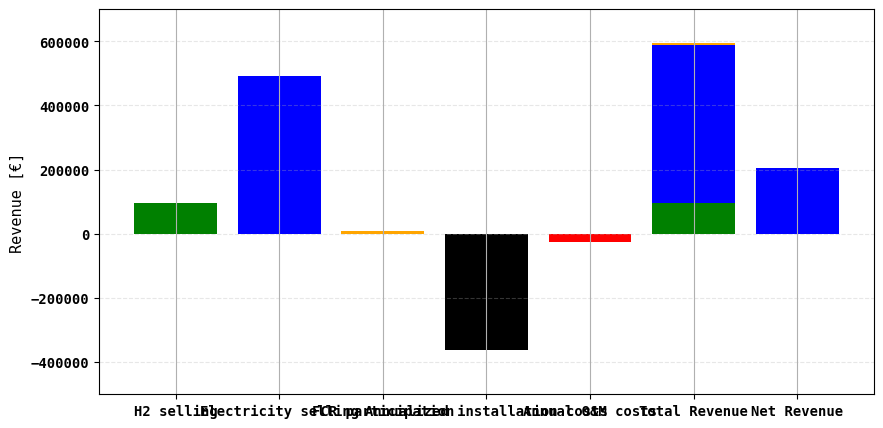

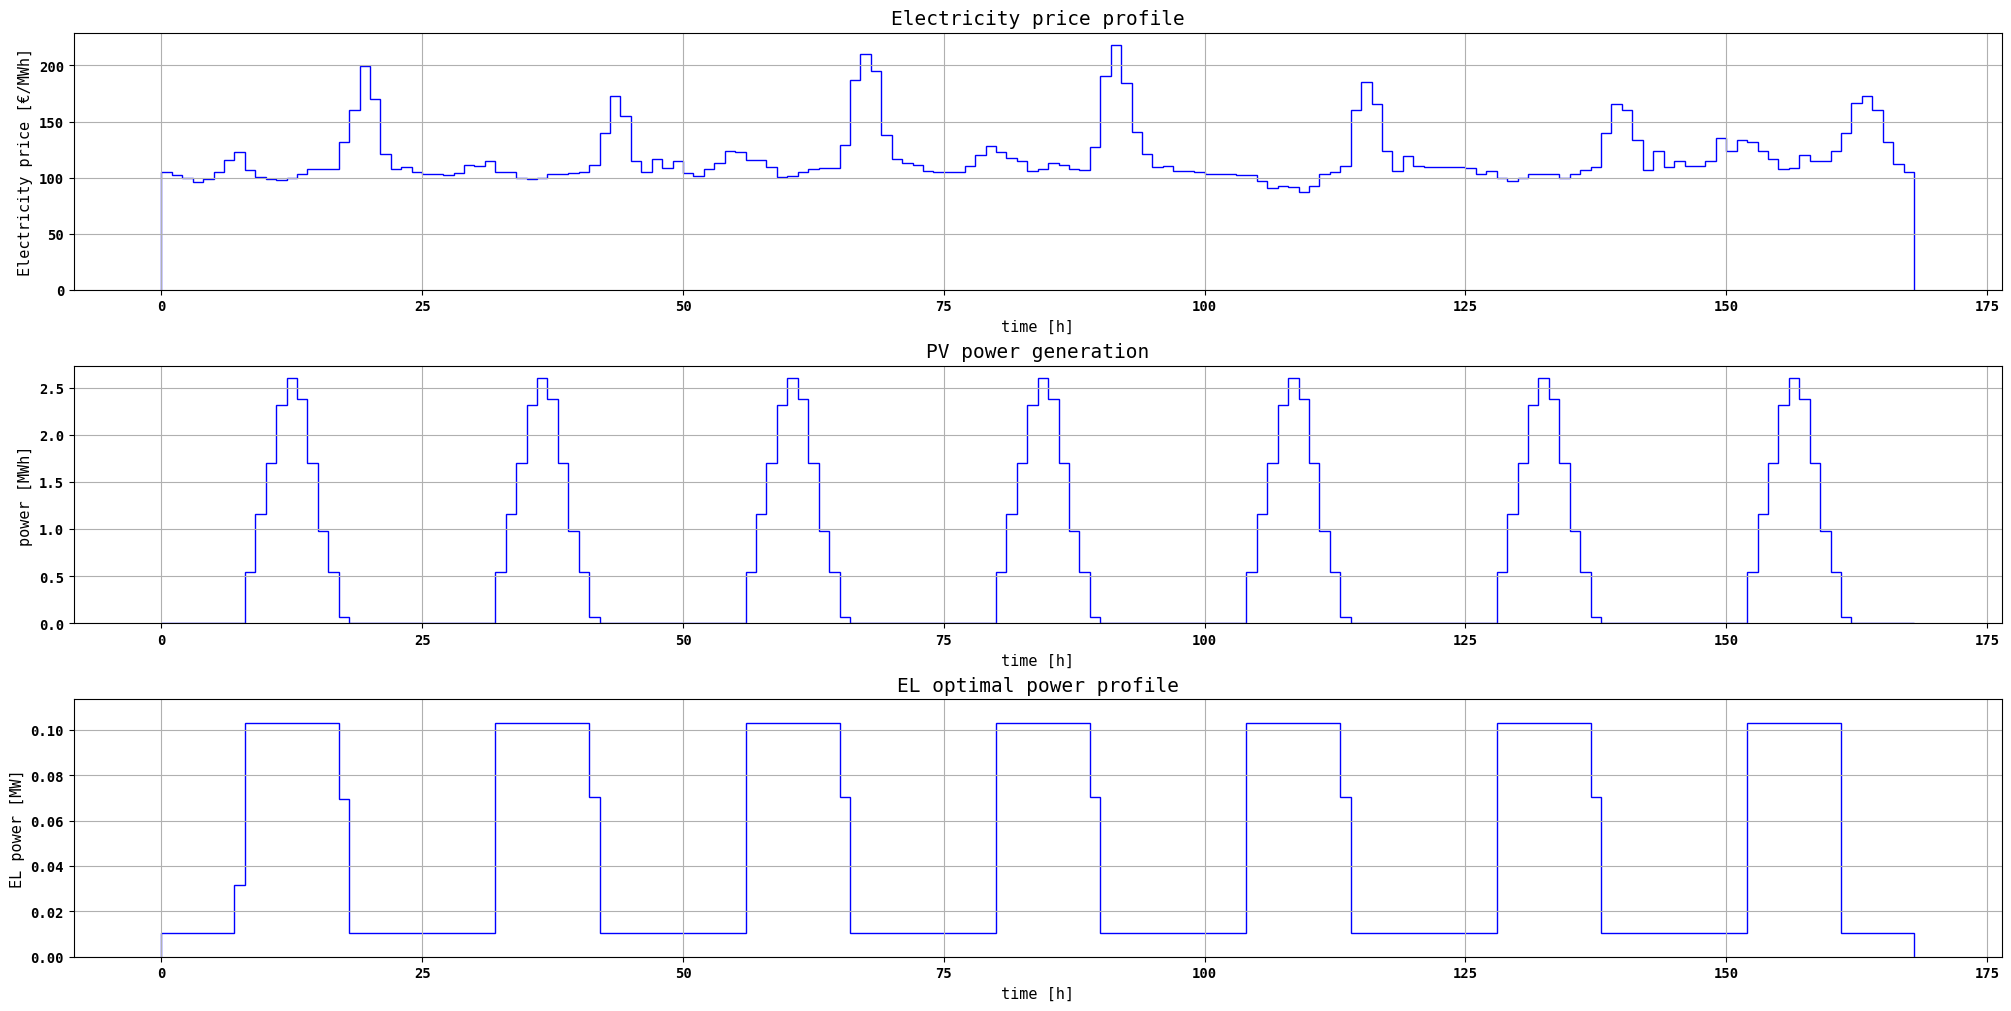

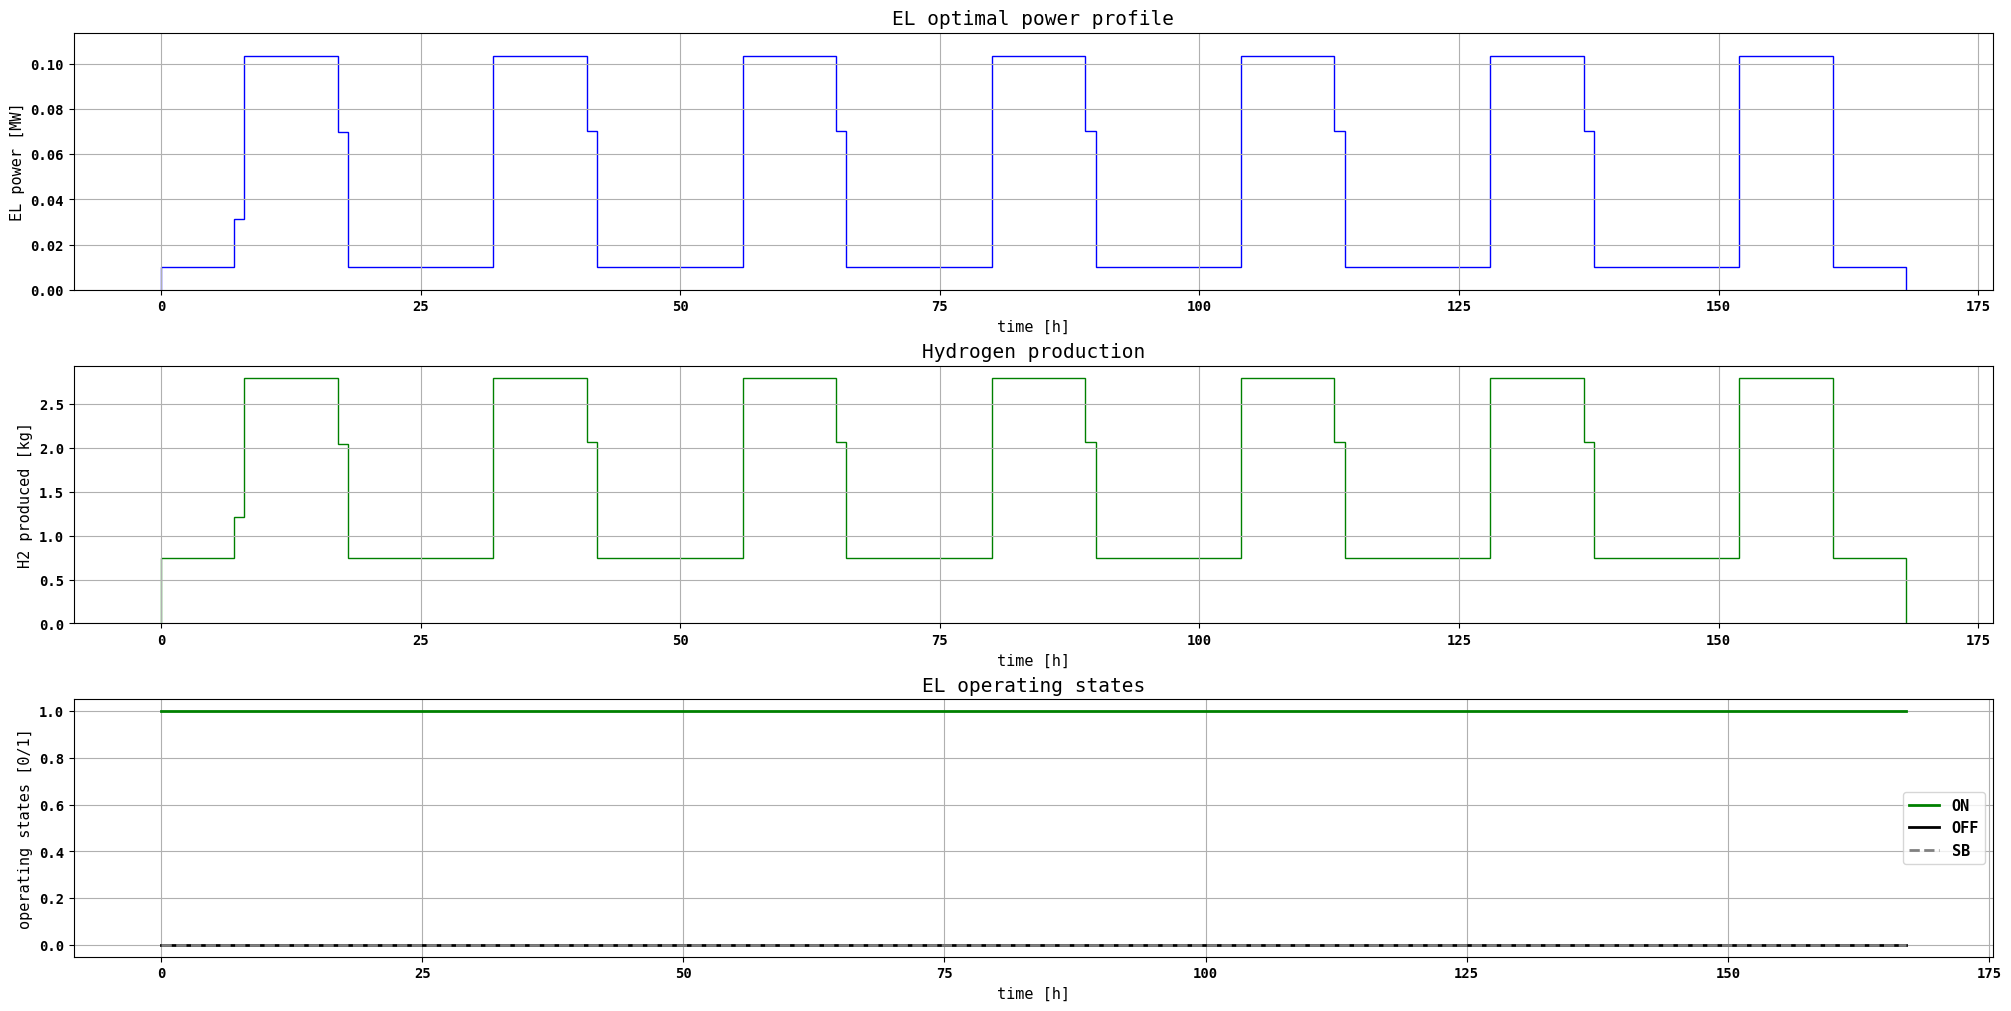

In [12]:
#------------------------------------------------------------------------------------------------
# PLOTTING (1/3)
#------------------------------------------------------------------------------------------------
time_plot = time[:time_window + 1]      # time array for plotting
day = 0                                 # specific day for plotting
# week = 20                               # specific week for plotting
# week2 = 34                              


# Plot settings ---------------------------------------------------------------------------------
plt.rc('figure', figsize=(20, 10))
plt.rc('font', family='monospace', weight='bold', size=11)
plt.rc('axes', labelsize=11, titlesize=14)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 2


# RESULTS PLOTS ---------------------------------------------------------------------------------
labels = ['H2 selling', 'Electricity selling', 'FCR participation', 'Annualized installation costs', 'Annual O&M costs']
colors = ["green", "blue", "orange", "black", "red"]
values = [rev_h2sell, rev_elecsell, rev_FCR, -ann_install_costs, -ann_om_costs]

plt.figure(figsize = (10, 5))
plt.bar(labels, values, color = colors)
plt.bar(['Total Revenue'], [rev_h2sell], label='Hydrogen', color = colors[0])
plt.bar(['Total Revenue'], [rev_elecsell], bottom=[rev_h2sell], label='Electricity', color = colors[1])
plt.bar(['Total Revenue'], [rev_FCR], bottom=[rev_h2sell + rev_elecsell], label='Other', color = colors[2])
plt.bar(['Net Revenue'], rev_tot, color = "blue")

plt.ylabel("Revenue [€]")
plt.ylim(-5e5, 7e5)
plt.grid(axis='y', linestyle='--', alpha=0.3)
# plt.tight_layout()
# plt.figure(figsize=(6,5))


# INPUT PLOTS -----------------------------------------------------------------------------------
# TIME WINDOW
# Electricity cost plot
figIN, axsIN = plt.subplots(3, 1, layout='constrained')
axsIN[0].stairs(C_ele_vals, time_plot, color = 'blue')
axsIN[0].set_xlabel('time [h]')
axsIN[0].set_ylabel('Electricity price [€/MWh]')
axsIN[0].set_title("Electricity price profile")
# PV power plot
axsIN[1].stairs(Ppv_vals, time_plot, color = 'blue')
axsIN[1].set_xlabel('time [h]')
axsIN[1].set_ylabel('power [MWh]')
axsIN[1].set_title("PV power generation")
# EL power plot
axsIN[2].stairs(pel_vals, time_plot, color = 'blue')
axsIN[2].set_xlabel('time [h]')
axsIN[2].set_ylabel('EL power [MW]')
axsIN[2].set_title("EL optimal power profile")
axsIN[2].set_ylim(0, 1.1 * m.Cel['EL'].value)

# # CHOSEN WEEK
# # Electricity cost plot
# figIN2, axsIN2 = plt.subplots(3, 1, layout='constrained')
# axsIN2[0].step(time_plot[week*24*7 : (week+1)*24*7], C_ele_vals[week*24*7 : (week+1)*24*7], color = 'blue')
# axsIN2[0].set_xlabel('time [h]')
# axsIN2[0].set_ylabel('Electricity price [€/MWh]')
# axsIN2[0].set_title("Electricity price profile (week 20)")
# # PV power plot
# axsIN2[1].step(time_plot[week*24*7 : (week+1)*24*7], Ppv_vals[week*24*7 : (week+1)*24*7], color = 'blue')
# axsIN2[1].set_xlabel('time [h]')
# axsIN2[1].set_ylabel('power [MWh]')
# axsIN2[1].set_title("PV power generation (week 20)")
# # EL power plot
# axsIN2[2].step(time_plot[week*24*7 : (week+1)*24*7], pel_vals[week*24*7 : (week+1)*24*7], color = 'blue')
# axsIN2[2].set_xlabel('time [h]')
# axsIN2[2].set_ylabel('EL power [MW]')
# axsIN2[2].set_title("EL optimal power profile (week 20)")
# axsIN2[2].set_ylim(0, 1.1 * Pel_rtd['EL'])


# EL PLOTS --------------------------------------------------------------------------------------
# TIME WINDOW
# EL power plot
figEL, axsEL = plt.subplots(3, 1, layout='constrained')
axsEL[0].stairs(pel_vals, time_plot, color = 'blue')
axsEL[0].set_xlabel('time [h]')
axsEL[0].set_ylabel('EL power [MW]')
axsEL[0].set_title("EL optimal power profile")
axsEL[0].set_ylim(0, 1.1 * m.Cel['EL'].value)
# Hydrogen production plot
axsEL[1].stairs(hel_vals, time_plot, color = 'green')
axsEL[1].set_xlabel('time [h]')
axsEL[1].set_ylabel('H2 produced [kg]')
axsEL[1].set_title("Hydrogen production")
# EL operating states plot
axsEL[2].step(time_plot[:-1], xel_on_vals, color = 'green', where='post', label = 'ON')
axsEL[2].step(time_plot[:-1], xel_off_vals, color = 'black', where='post', label = 'OFF')
axsEL[2].step(time_plot[:-1], xel_sb_vals, color = 'grey', where='post', linestyle='--', label = 'SB')
# axs[2].step(time_plot[day * 24 : (day+1) * 24], xel_su_vals[day * 24 : (day+1) * 24], color = 'red', where='post')
axsEL[2].set_xlabel('time [h]')
axsEL[2].set_ylabel('operating states [0/1]')
axsEL[2].set_title("EL operating states")
axsEL[2].legend()

# # CHOSEN WEEK
# # EL power plot
# figEL2, axsEL2 = plt.subplots(3, 1, layout='constrained')
# axsEL2[0].stairs(pel_vals[week*24*7 : (week+1)*24*7], time_plot[week*24*7 : (week+1)*24*7 + 1], color = 'blue')
# axsEL2[0].set_xlabel('time [h]')
# axsEL2[0].set_ylabel('EL power [MW]')
# axsEL2[0].set_title("EL optimal power profile (week 20)")
# axsEL2[0].set_xlim(week*24*7, (week+1)*24*7 + 1)
# axsEL2[0].set_ylim(0, 1.1 * Pel_rtd['EL'])
# # Hydrogen production plot
# axsEL2[1].stairs(hel_vals[week*24*7 : (week+1)*24*7], time_plot[week*24*7 : (week+1)*24*7 + 1], color = 'green')
# axsEL2[1].set_xlabel('time [h]')
# axsEL2[1].set_ylabel('H2 produced [kg]')
# axsEL2[1].set_title("Hydrogen production (week 20)")
# axsEL2[1].set_xlim(week*24*7, (week+1)*24*7 + 1)
# # EL operating states plot
# axsEL2[2].step(time_plot[week*24*7 : (week+1)*24*7], xel_on_vals[week*24*7 : (week+1)*24*7], color = 'green', where='post', label = 'ON')
# axsEL2[2].step(time_plot[week*24*7 : (week+1)*24*7], xel_off_vals[week*24*7 : (week+1)*24*7], color = 'black', where='post', label = 'OFF')
# axsEL2[2].step(time_plot[week*24*7 : (week+1)*24*7], xel_sb_vals[week*24*7 : (week+1)*24*7], color = 'grey', where='post', linestyle='--', label = 'SB')
# # axs[2].step(time_plot[day * 24 : (day+1) * 24], xel_su_vals[day * 24 : (day+1) * 24], color = 'red', where='post')
# axsEL2[2].set_xlabel('time [h]')
# axsEL2[2].set_ylabel('operating states [0/1]')
# axsEL2[2].set_title("EL operating states (week 20)")
# axsEL2[2].set_xlim(week*24*7, (week+1)*24*7 + 1)
# axsEL2[2].legend()

TypeError: Implicit conversion of Pyomo numeric value (1.6632904509914843*Cb_mwh[BESS]) to float is disabled.
This error is often the result of using Pyomo components as arguments to
one of the Python built-in math module functions when defining
expressions. Avoid this error by using Pyomo-provided math functions or
explicitly resolving the numeric value using the Pyomo value() function.

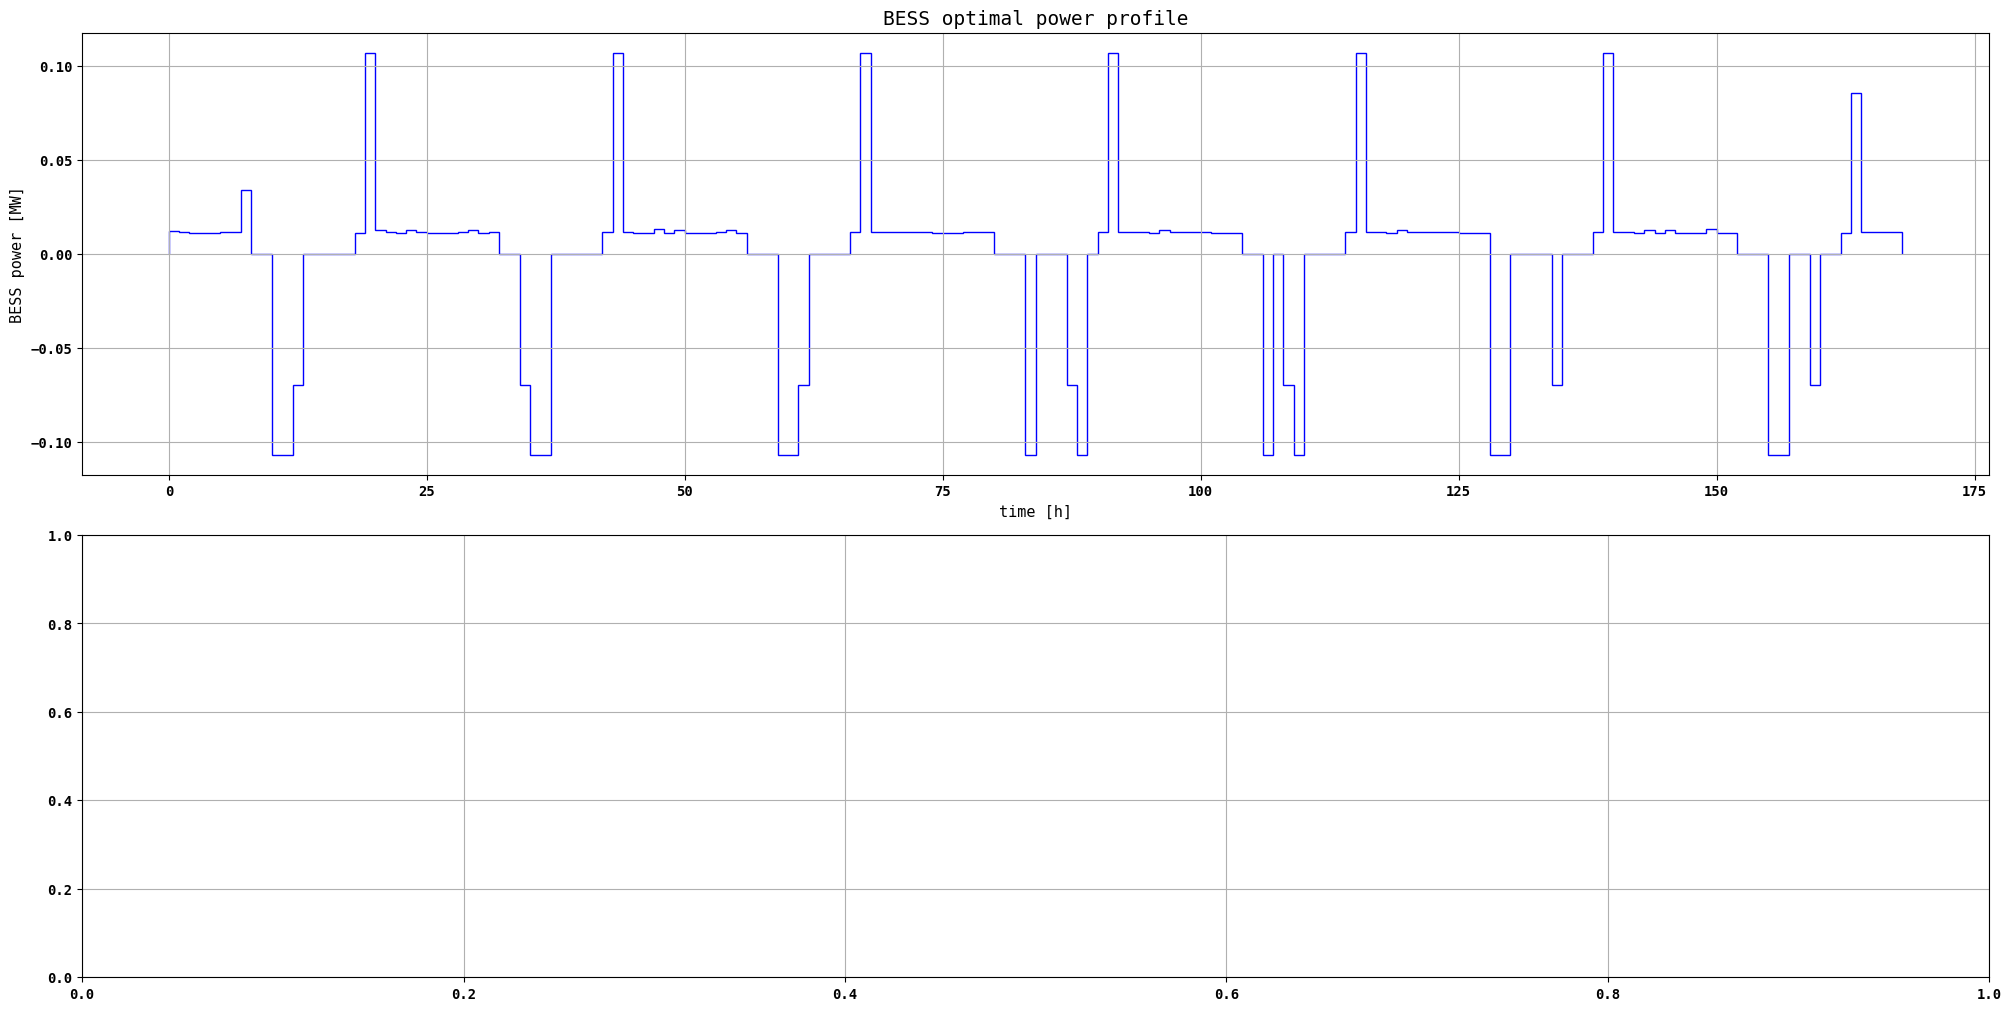

In [14]:
#------------------------------------------------------------------------------------------------
# PLOTTING (2/3)
#------------------------------------------------------------------------------------------------

# BESS PLOTS ------------------------------------------------------------------------------------
# TIME WINDOW
# BESS power plot
figBESS, axsBESS = plt.subplots(2, 1, layout='constrained')
axsBESS[0].stairs(pb_vals, time_plot, color = 'blue')
axsBESS[0].set_xlabel('time [h]')
axsBESS[0].set_ylabel('BESS power [MW]')
axsBESS[0].set_title("BESS optimal power profile")
# BESS SoC plot
axsBESS[1].plot(time_plot, eb_vals/m.Cb_mwh['BESS'].value, color = 'black')
axsBESS[1].set_xlabel('time [h]')
axsBESS[1].set_ylabel('SoC [p.u.]')
axsBESS[1].set_title("BESS State of Charge")
axsBESS[1].set_ylim(0, 1.1)
# # BESS operating states plot
# axs2[2].step(time_plot[week*24*7 : (week+1)*24*7], pb_dch_vals[week*24*7 : (week+1)*24*7] - pb_ch_vals[week*24*7 : (week+1)*24*7], color = 'blue')
# axs2[2].step(time_plot[week*24*7 : (week+1)*24*7], 0.5*xb_vals[week*24*7 : (week+1)*24*7], color = 'black')

# CHOSEN WEEK
# BESS power plot
figBESS2, axsBESS2 = plt.subplots(2, 1, layout='constrained')
axsBESS2[0].step(time_plot[week*24*7 : (week+1)*24*7], pb_vals[week*24*7 : (week+1)*24*7], color = 'blue')
axsBESS2[0].set_xlabel('time [h]')
axsBESS2[0].set_ylabel('BESS power [MW]')
axsBESS2[0].set_title("BESS optimal power profile (week 20)")
axsBESS2[0].set_xlim(week*24*7, (week+1)*24*7 + 1)
# BESS SoC plot
axsBESS2[1].plot(time_plot[week*24*7 : (week+1)*24*7], soc_vals[week*24*7 + 1 : (week+1)*24*7 + 1], color = 'black')  # SoC values are shifted forwards by 1 to match power plots
axsBESS2[1].set_xlabel('time [h]')
axsBESS2[1].set_ylabel('SoC [p.u.]')
axsBESS2[1].set_title("BESS State of Charge (week 20)")
axsBESS2[1].set_ylim(0, 1.1)
axsBESS2[1].set_xlim(week*24*7, (week+1)*24*7 + 1)


# HYDROGEN STORAGE PLOTS ------------------------------------------------------------------------
# TIME WINDOW
# HSS hydrogen level plot
figHSS, axsHSS = plt.subplots(2, 1, layout='constrained')
axsHSS[0].plot(time_plot, hhss_vals, color = 'black')
axsHSS[0].set_xlabel('time [h]')
axsHSS[0].set_ylabel('hydrogen level [kg]')
axsHSS[0].set_title("Hydrogen level in the storage tank")
axsHSS[0].set_ylim(0, 1.1 * H_hss_max['HSS'])
# Input and outputs of the HSS (without efficiencies)
axsHSS[1].step(time_plot[:-1], hel_vals, color = 'green', label = 'H2 from EL')
axsHSS[1].step(time_plot[:-1], hfc_vals, color = 'red', label = 'H2 to FC')
axsHSS[1].step(time_plot[:-1], hdem_vals, color = 'black', label = 'H2 to HRS')
axsHSS[1].set_xlabel('time [h]')
axsHSS[1].set_ylabel('hydrogen flows [kg]')
axsHSS[1].set_title("Storage tank input and output hydrogen flows")
axsHSS[1].set_ylim(0, 40)
axsHSS[1].legend()

# CHOSEN WEEK
# HSS hydrogen level plot
figHSS2, axsHSS2 = plt.subplots(2, 1, layout='constrained')
axsHSS2[0].plot(time_plot[week*24*7 : (week+1)*24*7], hhss_vals[week*24*7 + 1 : (week+1)*24*7 + 1], color = 'black')
axsHSS2[0].set_xlabel('time [h]')
axsHSS2[0].set_ylabel('hydrogen level [kg]')
axsHSS2[0].set_title("Hydrogen level in the storage tank (week 20)")
axsHSS2[0].set_ylim(0.95 * min(hhss_vals[week*24*7 + 1 : (week+1)*24*7 + 1]), 1.05 * max(hhss_vals[week*24*7 + 1 : (week+1)*24*7 + 1]))
axsHSS2[0].set_xlim(week*24*7, (week+1)*24*7 + 1)
# Input and outputs of the HSS (without efficiencies)
axsHSS2[1].step(time_plot[week*24*7 : (week+1)*24*7], hel_vals[week*24*7 : (week+1)*24*7], color = 'green', label = 'H2 from EL')
axsHSS2[1].step(time_plot[week*24*7 : (week+1)*24*7], hfc_vals[week*24*7 : (week+1)*24*7], color = 'red', label = 'H2 to FC')
axsHSS2[1].step(time_plot[week*24*7 : (week+1)*24*7], hdem_vals[week*24*7 : (week+1)*24*7], color = 'black', label = 'H2 to HRS')
axsHSS2[1].set_xlabel('time [h]')
axsHSS2[1].set_ylabel('hydrogen flows [kg]')
axsHSS2[1].set_title("Storage tank input and output hydrogen flows (week 20)")
axsHSS2[1].set_ylim(0, 40)
axsHSS2[1].set_xlim(week*24*7, (week+1)*24*7 + 1)
axsHSS2[1].legend()

# CHOSEN WEEK 2
# HSS hydrogen level plot
figHSS3, axsHSS3 = plt.subplots(2, 1, layout='constrained')
axsHSS3[0].plot(time_plot[week2*24*7 : (week2+1)*24*7], hhss_vals[week2*24*7 + 1 : (week2+1)*24*7 + 1], color = 'black')
axsHSS3[0].set_xlabel('time [h]')
axsHSS3[0].set_ylabel('hydrogen level [kg]')
axsHSS3[0].set_title("Hydrogen level in the storage tank (week 34)")
axsHSS3[0].set_xlim(week2*24*7, (week2+1)*24*7 + 1)
axsHSS3[0].set_ylim(0.95 * min(hhss_vals[week2*24*7 + 1 : (week2+1)*24*7 + 1]), 1.05 * max(hhss_vals[week2*24*7 + 1 : (week2+1)*24*7 + 1]))
# Input and outputs of the HSS (without efficiencies)
axsHSS3[1].step(time_plot[week2*24*7 : (week2+1)*24*7], hel_vals[week2*24*7 : (week2+1)*24*7], color = 'green', label = 'H2 from EL')
axsHSS3[1].step(time_plot[week2*24*7 : (week2+1)*24*7], hfc_vals[week2*24*7 : (week2+1)*24*7], color = 'red', label = 'H2 to FC')
axsHSS3[1].step(time_plot[week2*24*7 : (week2+1)*24*7], hdem_vals[week2*24*7 : (week2+1)*24*7], color = 'black', label = 'H2 to HRS')
axsHSS3[1].set_xlabel('time [h]')
axsHSS3[1].set_ylabel('hydrogen flows [kg]')
axsHSS3[1].set_title("Storage tank input and output hydrogen flows (week 34)")
axsHSS3[1].set_ylim(0, 40)
axsHSS3[1].set_xlim(week2*24*7, (week2+1)*24*7 + 1)
axsHSS3[1].legend()


# FC power plot
figFC, axsFC = plt.subplots(2, 1, layout='constrained')
axsFC[0].stairs(pfc_vals, time_plot, color = 'red')
axsFC[0].set_xlabel('time [h]')
axsFC[0].set_ylabel('FC power [MW]')
axsFC[0].set_title("FC optimal power profile")
axsFC[0].set_ylim(0, 1.1 * Pfc_rtd['FC'])

In [ ]:
#------------------------------------------------------------------------------------------------
# PLOTTING (3/3)
#------------------------------------------------------------------------------------------------

# FCR EL PLOTS ----------------------------------------------------------------------------------
# TIME WINDOW
# FCR EL capacity allocation plot, downward regulation
figFCRel, axsFCRel = plt.subplots(2, 1, layout = 'constrained')
axsFCRel[0].step(time_plot[:-1], pel_vals + pel_fcr_dwn_vals, color = 'blue', label = 'EL power + downward FCR')
axsFCRel[0].step(time_plot[:-1], pel_vals, color = 'black', label = 'EL power')
axsFCRel[0].set_xlabel('time [h]')
axsFCRel[0].set_ylabel('allocated FCR capacity [MW]')
axsFCRel[0].set_title("Downward FCR regulation of the EL")
axsFCRel[0].set_ylim(-0.1, 1.1 * Pel_rtd['EL'])
axsFCRel[0].legend()
# FCR EL capacity allocation plot, upward regulation
axsFCRel[1].step(time_plot[:-1], pel_vals - pel_fcr_up_vals, color = 'blue', label = 'EL power - upward FCR')
axsFCRel[1].step(time_plot[:-1], pel_vals, color = 'black', label = 'EL power')
axsFCRel[1].set_xlabel('time [h]')
axsFCRel[1].set_ylabel('allocated FCR capacity [MW]')
axsFCRel[1].set_title("Upward FCR regulation of the EL")
axsFCRel[1].set_ylim(-0.1, 1.1 * Pel_rtd['EL'])
axsFCRel[1].legend()

# CHOSEN WEEK
# FCR EL capacity allocation plot, downward regulation
figFCRel, axsFCRel = plt.subplots(2, 1, layout = 'constrained')
axsFCRel[0].step(time_plot[week*24*7 : (week+1)*24*7], pel_vals[week*24*7 : (week+1)*24*7] + pel_fcr_dwn_vals[week*24*7 : (week+1)*24*7], color = 'blue', label = 'EL power + downward FCR')
axsFCRel[0].step(time_plot[week*24*7 : (week+1)*24*7], pel_vals[week*24*7 : (week+1)*24*7], color = 'black', label = 'EL power')
axsFCRel[0].set_xlabel('time [h]')
axsFCRel[0].set_ylabel('allocated FCR capacity [MW]')
axsFCRel[0].set_title("Downward FCR regulation of the EL (week 20)")
axsFCRel[0].set_ylim(-0.1, 1.1 * Pel_rtd['EL'])
axsFCRel[0].legend()
# FCR EL capacity allocation plot, upward regulation
axsFCRel[1].step(time_plot[week*24*7 : (week+1)*24*7], pel_vals[week*24*7 : (week+1)*24*7] - pel_fcr_up_vals[week*24*7 : (week+1)*24*7], color = 'blue', label = 'EL power - upward FCR')
axsFCRel[1].step(time_plot[week*24*7 : (week+1)*24*7], pel_vals[week*24*7 : (week+1)*24*7], color = 'black', label = 'EL power')
axsFCRel[1].set_xlabel('time [h]')
axsFCRel[1].set_ylabel('allocated FCR capacity [MW]')
axsFCRel[1].set_title("Upward FCR regulation of the EL (week 20)")
axsFCRel[1].set_ylim(-0.1, 1.1 * Pel_rtd['EL'])
axsFCRel[1].legend()


# FCR FC PLOTS ----------------------------------------------------------------------------------
# TIME WINDOW
# FCR FC capacity allocation plot, downward regulation
figFCRfc, axsFCRfc = plt.subplots(2, 1, layout = 'constrained')
axsFCRfc[0].step(time_plot[:-1], pfc_vals + pfc_fcr_up_vals, color = 'blue', label = 'FC power + downward FCR')
axsFCRfc[0].step(time_plot[:-1], pfc_vals, color = 'black', label = 'FC power')
axsFCRfc[0].set_xlabel('time [h]')
axsFCRfc[0].set_ylabel('allocated FCR capacity [MW]')
axsFCRfc[0].set_title("Downward FCR regulation of the FC")
axsFCRfc[0].set_ylim(-0.05, 1.1 * Pfc_rtd['FC'])
axsFCRfc[0].legend()
# FCR FC capacity allocation plot, upward regulation
axsFCRfc[1].step(time_plot[:-1], pfc_vals - pfc_fcr_dwn_vals, color = 'blue', label = 'FC power - upward FCR')
axsFCRfc[1].step(time_plot[:-1], pfc_vals, color = 'black', label = 'FC power')
axsFCRfc[1].set_xlabel('time [h]')
axsFCRfc[1].set_ylabel('allocated FCR capacity [MW]')
axsFCRfc[1].set_title("Upward FCR regulation of the FC")
axsFCRfc[1].set_ylim(-0.05, 1.1 * Pfc_rtd['FC'])
axsFCRfc[1].legend()

# CHOSEN WEEK
# FCR FC capacity allocation plot, downward regulation
figFCRfc, axsFCRfc = plt.subplots(2, 1, layout = 'constrained')
axsFCRfc[0].step(time_plot[week2*24*7 : (week2+1)*24*7], pfc_vals[week2*24*7 : (week2+1)*24*7] + pfc_fcr_up_vals[week2*24*7 : (week2+1)*24*7], color = 'blue', label = 'FC power + downward FCR')
axsFCRfc[0].step(time_plot[week2*24*7 : (week2+1)*24*7], pfc_vals[week2*24*7 : (week2+1)*24*7], color = 'black', label = 'FC power')
axsFCRfc[0].set_xlabel('time [h]')
axsFCRfc[0].set_ylabel('allocated FCR capacity [MW]')
axsFCRfc[0].set_title("Downward FCR regulation of the FC (week 34)")
axsFCRfc[0].set_ylim(-0.05, 1.1 * Pfc_rtd['FC'])
axsFCRfc[0].legend()
# FCR EL capacity allocation plot, upward regulation
axsFCRfc[1].step(time_plot[week2*24*7 : (week2+1)*24*7], pfc_vals[week2*24*7 : (week2+1)*24*7] - pfc_fcr_dwn_vals[week2*24*7 : (week2+1)*24*7], color = 'blue', label = 'FC power - upward FCR')
axsFCRfc[1].step(time_plot[week2*24*7 : (week2+1)*24*7], pfc_vals[week2*24*7 : (week2+1)*24*7], color = 'black', label = 'FC power')
axsFCRfc[1].set_xlabel('time [h]')
axsFCRfc[1].set_ylabel('allocated FCR capacity [MW]')
axsFCRfc[1].set_title("Upward FCR regulation of the FC (week 34)")
axsFCRfc[1].set_ylim(-0.05, 1.1 * Pfc_rtd['FC'])
axsFCRfc[1].legend()

In [ ]:
0.7 / (2.2*400*66/1000)

1 * 0.75 / 33.3e-3